# Data Science Project

## Project overview

This notebook contains the complete implementation of the project *Intelligent System for Autonomous Assistance in Elderly Care Homes*. It follows the same three-phase structure described in the technical report and is designed to be read as an executable complement to it.

The objective of this notebook is to show, step by step, how raw sensor data is transformed into meaningful behavioral information, how alerts are generated through a combination of heuristic rules and machine learning models (AI agent), and how the full system operates under simulated real-time conditions.

The project is organized into three main phases:

- **Phase 1: Exploration and unsupervised analysis**  
  This phase covers data loading, preprocessing, exploratory data analysis and state definition. The goal is to understand normal behavioral patterns and identify unusual situations without relying on labeled data.

- **Phase 2: Supervised modeling and agent design**  
  In this phase, a supervised model is trained to predict resident behavioral states. On top of this, a deterministic alert system is defined using interpretable heuristic rules. A decision-making agent based on a language model is integrated only for ambiguous cases where rules alone are insufficient.

- **Phase 3: Real-time operation and visualization**  
  The final phase simulates a real-time streaming scenario, where sensor data is processed sequentially without access to future information. At each time step, resident states are predicted, alerts are generated, decisions are logged, and results are visualized through an interactive dashboard.

Throughout the notebook, emphasis is placed on interpretability, reproducibility, and safety-oriented decision making. The code prioritizes clarity over optimization, with comments and markdown explanations provided to justify key design choices and to facilitate understanding of the complete pipeline.


To run the notebook, the following files are needed:

- fase_2_con_estados.csv
- fase_3_sin_estados.csv
- best_lstm_attention_model.pt


## Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import math
import numpy as np
from sklearn.ensemble import IsolationForest

from sklearn.cluster import KMeans
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

!pip install --quiet gradio openai

import time
import json
import gradio as gr
from openai import OpenAI
import gradio as gr
import random

Decide if the neural network must be trained or use loaded weights

In [2]:
training = False

# Phase 1

## Data loading and EDA

Phase 2 data with states (3 days)

In [3]:
df = pd.read_csv('fase_2_con_estados.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()

,resident_id,timestamp,resident_state,location_x,location_y,radar_event,bed_presence,wearable_location,accelerometer_z,pulse_bpm,wearable_alert,door_state,room_light,smoke_ppm,temperature_c,humidity_perc
0,1,2025-09-29 00:00:00,SLEEPING,1.03,1.79,static_presence,present,room,-0.89,67,False,closed,off,6.2,21.8,30.2
1,1,2025-09-29 00:01:00,SLEEPING,1.27,2.40,static_presence,present,room,-1.07,68,False,closed,off,5.4,21.8,30.0
2,1,2025-09-29 00:02:00,SLEEPING,1.65,2.22,static_presence,present,room,-0.77,66,False,closed,off,4.8,21.5,29.4
3,1,2025-09-29 00:03:00,SLEEPING,1.00,2.29,static_presence,present,room,-1.03,67,False,closed,off,4.5,21.2,27.3
4,1,2025-09-29 00:04:00,SLEEPING,1.25,1.42,static_presence,present,room,-1.26,73,False,closed,off,6.1,21.2,27.5


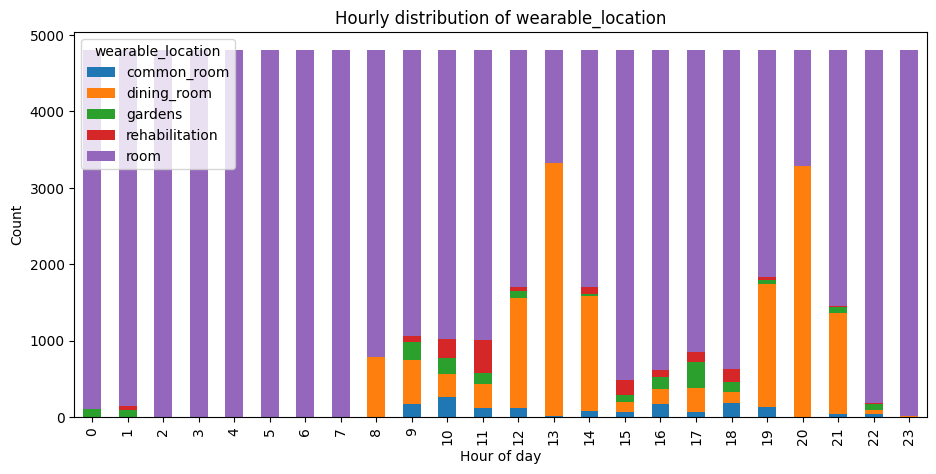

In [4]:
def hourly_counts(col):
    if col not in df.columns:
        return pd.DataFrame()
    tbl = (df.groupby("hour")[col]
           .value_counts()
           .unstack(fill_value=0)
           .sort_index())
    return tbl

df['hour'] = df['timestamp'].dt.hour
hourly_wear  = hourly_counts("wearable_location")

for name, tbl in [("wearable_location", hourly_wear)]:
    if tbl.empty:
        continue
    ax = tbl.plot(kind="bar", stacked=True, figsize=(11,5), legend=True)
    ax.set_title(f"Hourly distribution of {name}")
    ax.set_xlabel("Hour of day")
    ax.set_ylabel("Count")
    fig = ax.get_figure()
    plt.show()

With the plot above we define the sleeping hours (22h- 8h)

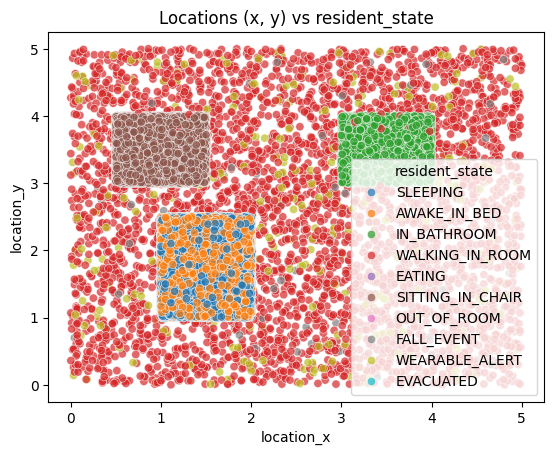

In [5]:
var = "resident_state"
sns.scatterplot(data=df, x='location_x', y='location_y', hue = var, alpha=0.7)
plt.title(f"Locations (x, y) vs {var}")
plt.show()

In the plot above one can observe that for each room in the care home there are three places where residents can walk: bedroom, bathroom or dining room or table

Here is an example of a simple anomaly detection using rolling mean. Later on we would do a more in depth study using Isolation Forest methods.

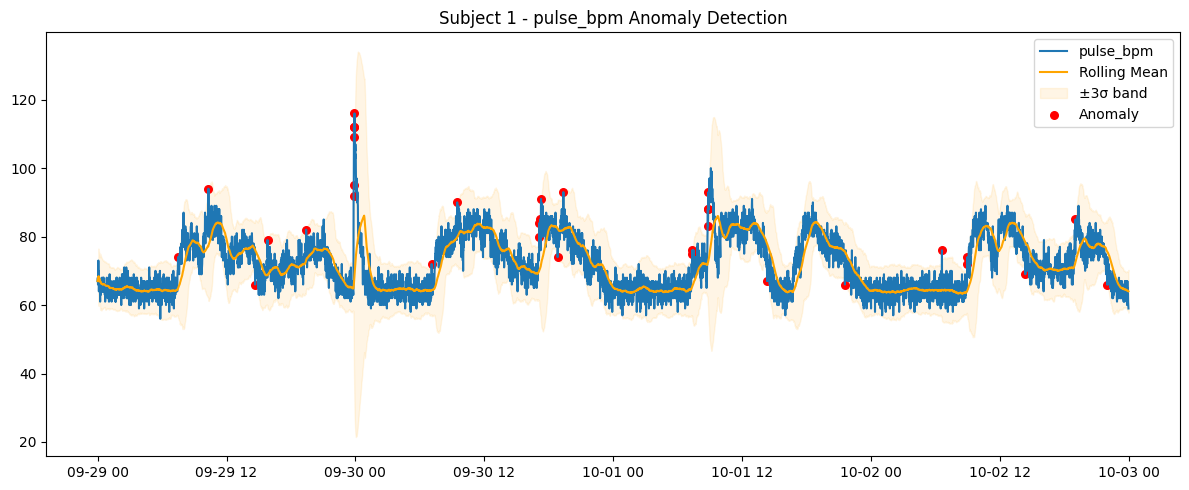

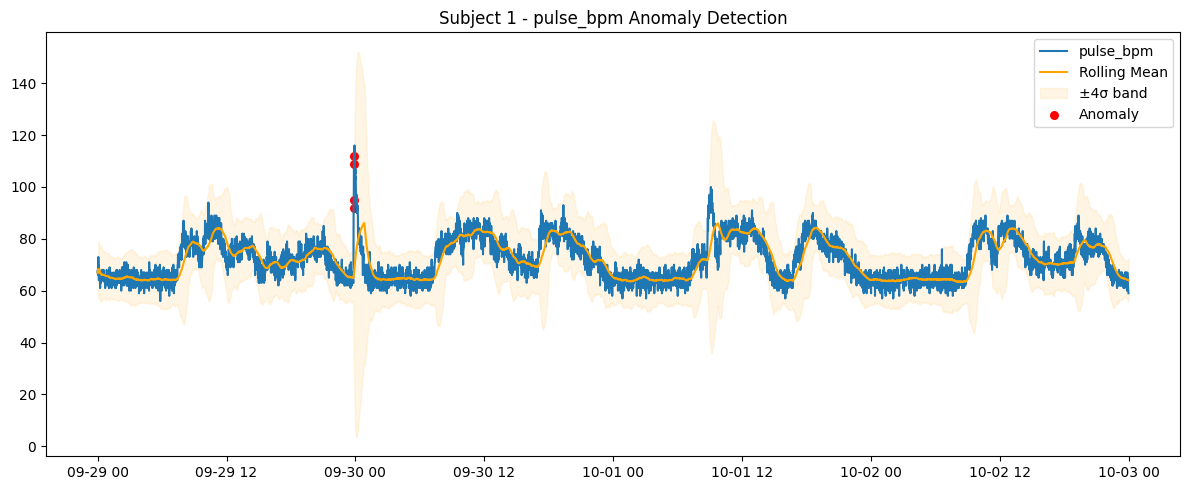

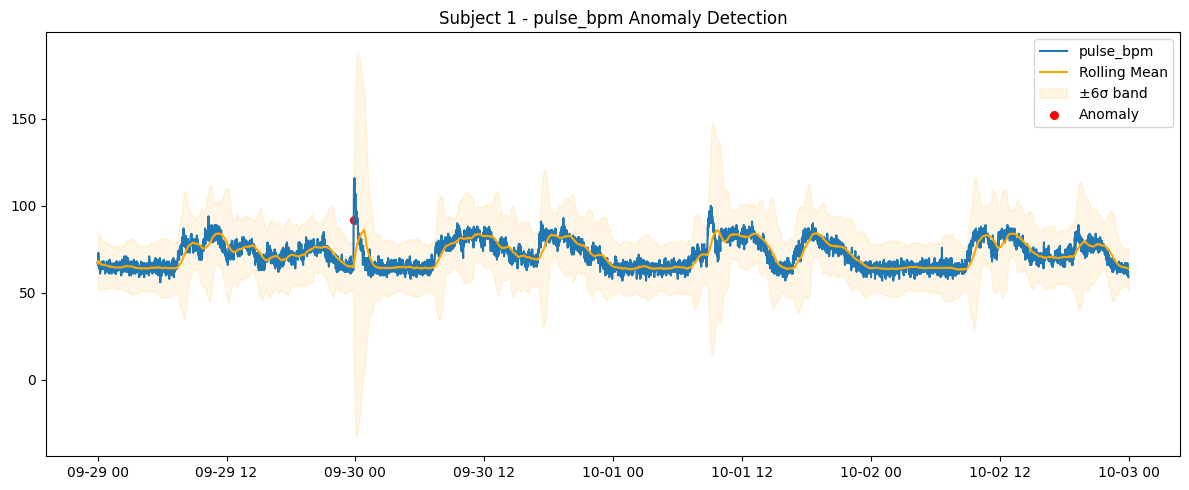

In [6]:
def detect_anomalies_for_subject(df_sub, variable, window, threshold):
    """Detect anomalies for a single subject using rolling mean/std and Z-score."""
    ts = df_sub.set_index("timestamp")[variable]
    rolling = ts.rolling(window=window, min_periods=1)
    mean = rolling.mean()
    std = rolling.std()
    z_score = (ts - mean) / std
    is_anomaly = z_score.abs() > threshold

    return pd.DataFrame({
        "timestamp": ts.index,
        variable: ts.values,
        "rolling_mean": mean.values,
        "rolling_std": std.values,
        "z_score": z_score.values,
        "is_anomaly": is_anomaly.values
    })


def detect_anomalies(df, variable, window=60, threshold=4, sids=None):
    """Run anomaly detection for multiple subjects and return combined dataframe."""
    df = df.sort_values(["resident_id", "timestamp"]).copy()

    if sids is None:
        sids = df["resident_id"].unique()

    all_results = []
    for sid in sids:
        df_sub = df[df["resident_id"] == sid][["timestamp", "resident_id", variable]].copy()
        result = detect_anomalies_for_subject(df_sub, variable, window, threshold)
        result["resident_id"] = sid
        all_results.append(result)

    return pd.concat(all_results, ignore_index=True)


def summarize_anomalies(df_anomalies):
    """Return summary of anomalies per subject."""
    summary = (df_anomalies.groupby("resident_id")["is_anomaly"]
               .sum()
               .reset_index()
               .rename(columns={"is_anomaly": "num_anomalies"}))
    return summary


def plot_anomalies(df_anomalies, variable, threshold=4, subjects=None):
    """Plot anomaly detection results for selected subjects."""
    if subjects is None:
        subjects = df_anomalies["resident_id"].unique()

    for sid in subjects:
        subset = df_anomalies[df_anomalies["resident_id"] == sid]

        plt.figure(figsize=(12, 5))
        plt.plot(subset["timestamp"], subset[variable], label=variable)
        plt.plot(subset["timestamp"], subset["rolling_mean"], color="orange", label="Rolling Mean")
        plt.fill_between(subset["timestamp"],
                         subset["rolling_mean"] - threshold * subset["rolling_std"],
                         subset["rolling_mean"] + threshold * subset["rolling_std"],
                         color="orange", alpha=0.1, label=f"±{threshold}σ band")
        plt.scatter(subset["timestamp"][subset["is_anomaly"]],
                    subset[variable][subset["is_anomaly"]],
                    color="red", s=30, label="Anomaly")
        plt.title(f"Subject {sid} - {variable} Anomaly Detection")
        plt.legend()
        plt.tight_layout()
        plt.show()

# Configuration
VARIABLE = "pulse_bpm"
WINDOW = 60
SIDS = [1]

# Detect anomalies
df_anomalies_TH3 = detect_anomalies(df, VARIABLE, window=WINDOW, threshold=3, sids=SIDS)
df_anomalies_TH4 = detect_anomalies(df, VARIABLE, window=WINDOW, threshold=4, sids=SIDS)
df_anomalies_TH5 = detect_anomalies(df, VARIABLE, window=WINDOW, threshold=6, sids=SIDS)

# Plot results (optional)
plot_anomalies(df_anomalies_TH3, VARIABLE, threshold=3, subjects=SIDS)
plot_anomalies(df_anomalies_TH4, VARIABLE, threshold=4, subjects=SIDS)
plot_anomalies(df_anomalies_TH5, VARIABLE, threshold=6, subjects=SIDS)

The peaks in the time series represent the anomalies of the residents

Resident name, age and condition

In [7]:
resident_data = [
    ("Adela Arco-Llano", 72, "Sin condición"),
    ("Cristian Cazorla Cazorla", 66, "Alzheimer"),
    ("Quique Ferrándiz Peñas", 72, "Sin condición"),
    ("Flora Anna Peinado Mir", 70, "Sin condición"),
    ("Jesús Huertas Osorio", 77, "Alzheimer"),
    ("José Mari Palomo Gárate", 97, "Movilidad reducida"),
    ("Adrián de Fuentes", 78, "Alzheimer"),
    ("Amanda Ordóñez Gomez", 84, "Alzheimer"),
    ("Clímaco Merino Barón", 75, "Alzheimer"),
    ("Graciela Zamorano Vergara", 71, "Alzheimer"),
    ("Julieta Castilla", 83, "Sin condición"),
    ("Tecla Cases Alcázar", 86, "Alzheimer"),
    ("Santiago Ayuso-Miralles", 99, "Alzheimer"),
    ("Severo Cañete-Estrada", 73, "Alzheimer"),
    ("Enrique Posada Adadia", 100, "Alzheimer"),
    ("Donato Requena Jurado", 89, "Sin condición"),
    ("Aníbal Bermudez Gual", 95, "Sin condición"),
    ("Arturo Lerma Feijoo", 86, "Alzheimer"),
    ("Pío Echevarría Sureda", 94, "Movilidad reducida"),
    ("Valentina Blanco Miguel", 89, "Sin condición"),
]



df_residents = pd.DataFrame(resident_data, columns=["name","age", "condition"])
df_residents["resident_id"] = range(1, len(df_residents)+1)
df_residents

df = df.merge(df_residents, on="resident_id", how="left")


Checking types

In [8]:
print(df.dtypes)

resident_id                   int64
timestamp            datetime64[ns]
resident_state               object
location_x                  float64
location_y                  float64
radar_event                  object
bed_presence                 object
wearable_location            object
accelerometer_z             float64
pulse_bpm                     int64
wearable_alert                 bool
door_state                   object
room_light                   object
smoke_ppm                   float64
temperature_c               float64
humidity_perc               float64
hour                          int32
name                         object
age                           int64
condition                    object
dtype: object


 Reviewing object columns to differentiate between categorical, boolean and datetime

In [9]:
numerical_cols = [
    'resident_id',
    'location_x',
    'location_y',
    'age',
    'accelerometer_z',
    'pulse_bpm',
    'smoke_ppm',
    'temperature_c',
    'humidity_perc'
]

boolean_cols = ['wearable_alert']
categorical_cols = []
datetime_cols = []


object_cols = df.select_dtypes(include='object').columns.tolist()

print("Reviewing object columns:")
for col in object_cols:

    if df[col].nunique() == 2:
        # convert to boolean
        df[col] = df[col].astype('bool')
        boolean_cols.append(col)
    else:
        categorical_cols.append(col)

    # Check if 'timestamp' is truly a datetime
    if col == 'timestamp':
        try:
            pd.to_datetime(df[col], errors='raise')
            datetime_cols.append(col)
        except Exception:
            print(f"'{col}' is an object column but not easily converted to datetime, keeping as potential categorical/text.")

# Add the new 'is_out_of_room' feature to categorical_cols
boolean_cols.append('is_out_of_room')

print(f"\nNumerical Columns: {numerical_cols}")
print(f"Boolean Columns: {boolean_cols}")
print(f"Categorical Columns: {categorical_cols}")
print(f"Datetime Columns: {datetime_cols}")

Reviewing object columns:

Numerical Columns: ['resident_id', 'location_x', 'location_y', 'age', 'accelerometer_z', 'pulse_bpm', 'smoke_ppm', 'temperature_c', 'humidity_perc']
Boolean Columns: ['wearable_alert', 'bed_presence', 'door_state', 'room_light', 'is_out_of_room']
Categorical Columns: ['resident_state', 'radar_event', 'wearable_location', 'name', 'condition']
Datetime Columns: []


The NA values of location are imputed as 0 (out of room)
The rest of numerical variables with the median to be sensitive to outliers

In [10]:
df_cleaned = df.copy()

for col in numerical_cols:
    # Replace NA values for 0's in the location
    if col in ['location_x', 'location_y']:
        if df_cleaned[col].isnull().any():
            df_cleaned[col] = df_cleaned[col].fillna(0)
            print(f"Replaced NaN in '{col}' with 0 (indicating out-of-room).")
        continue

    # For other numerical columns, use median imputation
    if df_cleaned[col].isnull().any():
        median_val = df_cleaned[col].median()
        df_cleaned[col].fillna(median_val)
        print(f"Imputed missing values in '{col}' with median: {median_val}")

# There are no missing values in categorical columns based on the previous output,
# but if there were, the imputation would look like this:
for col in categorical_cols:
    if df_cleaned[col].isnull().any():
        mode_val = df_cleaned[col].mode()[0]
        df_cleaned[col].fillna(mode_val)
        print(f"Imputed missing values in categorical '{col}' with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df_cleaned.isnull().sum())

# create new variable to take into account ehe missing location values
df_cleaned['is_out_of_room'] = (df['location_x'].isnull() | df['location_y'].isnull())


Replaced NaN in 'location_x' with 0 (indicating out-of-room).
Replaced NaN in 'location_y' with 0 (indicating out-of-room).

Missing values after imputation:
resident_id          0
timestamp            0
resident_state       0
location_x           0
location_y           0
radar_event          0
bed_presence         0
wearable_location    0
accelerometer_z      0
pulse_bpm            0
wearable_alert       0
door_state           0
room_light           0
smoke_ppm            0
temperature_c        0
humidity_perc        0
hour                 0
name                 0
age                  0
condition            0
dtype: int64


**Reasoning**:
Since most categorical columns are nominal and some have only two unique values, One-Hot Encoding is a suitable and common technique to convert them into a numerical format without implying any order. This will expand the DataFrame by creating new binary columns for each unique category.



In [11]:
print("Applying One-Hot Encoding to categorical columns...")

df_encoded = df_cleaned.copy()

# Drop the 'timestamp' column before encoding as it's a datetime and will be handled separately if needed for time-series analysis
# Also drop 'outlier_label' and 'outlier_score' as they were for outlier detection and are not features for modeling
df_encoded = df_encoded.drop(columns=['timestamp'])
#####
categorical_cols = [c for c in categorical_cols if c in df_encoded.columns]

# Apply One-Hot Encoding to the categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)


df_encoded.head()

Applying One-Hot Encoding to categorical columns...


,resident_id,location_x,location_y,bed_presence,accelerometer_z,pulse_bpm,wearable_alert,door_state,room_light,smoke_ppm,...,name_José Mari Palomo Gárate,name_Julieta Castilla,name_Pío Echevarría Sureda,name_Quique Ferrándiz Peñas,name_Santiago Ayuso-Miralles,name_Severo Cañete-Estrada,name_Tecla Cases Alcázar,name_Valentina Blanco Miguel,condition_Movilidad reducida,condition_Sin condición
0,1,1.03,1.79,True,-0.89,67,False,True,True,6.2,...,False,False,False,False,False,False,False,False,False,True
1,1,1.27,2.40,True,-1.07,68,False,True,True,5.4,...,False,False,False,False,False,False,False,False,False,True
2,1,1.65,2.22,True,-0.77,66,False,True,True,4.8,...,False,False,False,False,False,False,False,False,False,True
3,1,1.00,2.29,True,-1.03,67,False,True,True,4.5,...,False,False,False,False,False,False,False,False,False,True
4,1,1.25,1.42,True,-1.26,73,False,True,True,6.1,...,False,False,False,False,False,False,False,False,False,True


**Reasoning**:
Now that the numerical columns for scaling have been identified, I will apply `StandardScaler` to these columns in the `df_scaled` DataFrame. This will transform the data to have a mean of 0 and a standard deviation of 1, which is crucial for many machine learning algorithms.



## Pipeline official

The code below processes the original data through a pipeline to clean and prepare it for the next steps

In [12]:
# Custom Transformer to create 'is_out_of_room' feature
# This makes the pipeline start from a DataFrame that might not yet have this feature.
class AddIsOutOfRoomFeature(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        # Create 'is_out_of_room' based on missingness of location_x or location_y
        if 'location_x' in X_copy.columns and 'location_y' in X_copy.columns:
            X_copy['is_out_of_room'] = X_copy['location_x'].isnull() | X_copy['location_y'].isnull()
        else:
            # Default to False if location columns are not present, or handle as error
            X_copy['is_out_of_room'] = False
        return X_copy

# Convert radar_event to numeric values BEFORE the ColumnTransformer
class MapRadarEventToNumeric(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_copy = X.copy()
        mapping = {
            'absent': 0,
            'static_presence': 1,
            'slight_movement': 2,
            'active_movement': 3
        }
        if 'radar_event' in X_copy.columns:
            X_copy['radar_event'] = X_copy['radar_event'].map(mapping).fillna(-1)
        return X_copy


# Define the feature sets based on previous analysis
# Numerical features that need imputation (median) and then scaling
numerical_features_to_scale_only = ['location_x', 'location_y']

# Numerical features that only need scaling (already confirmed no NAs after initial checks)
numerical_features_to_impute_and_scale = [
    'accelerometer_z',
    'pulse_bpm',
    'smoke_ppm',
    'temperature_c',
    'humidity_perc'
]

# All categorical and boolean features that need one-hot encoding
# radar_event REMOVED from here (now numeric and NOT scaled)
categorical_features_for_onehot = [
    'wearable_location',
    'wearable_alert',
    'bed_presence',
    'door_state',
    'room_light',
    'is_out_of_room',
    'condition'
]


# Create preprocessing pipelines for different types of features

# Pipeline for numerical features that need imputation
numerical_impute_scale_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')) # Using median as per previous imputation strategy
])

# Pipeline for numerical features that only need scaling (location) and fill with 0's the NA values
numerical_scale_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

# Pipeline for categorical features
categorical_pipeline = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first')) # drop='first' for multicollinearity, handle_unknown='ignore' for robustness
])

# Combine all preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num_impute_scale', numerical_impute_scale_pipeline, numerical_features_to_impute_and_scale),
        ('num_scale', numerical_scale_pipeline, numerical_features_to_scale_only),
        ('cat', categorical_pipeline, categorical_features_for_onehot),
        ('radar_pass', 'passthrough', ['radar_event']),
        ('id_pass', 'passthrough', ['resident_id']),
        ('timestamp_pass', 'passthrough', ['timestamp']),
        ('state_pass', 'passthrough', ['resident_state']),
        ('age_pass', 'passthrough', ['age']),
        ('name_pass', 'passthrough', ['name'])

    ],
    remainder='drop'
)

# Create the full preprocessing pipeline
# This pipeline starts from the original 'df' and applies all transformations sequentially.
full_preprocessing_pipeline = Pipeline(steps=[
    ('map_radar', MapRadarEventToNumeric()),        # numeric mapping
    ('add_is_out_of_room', AddIsOutOfRoomFeature()), # First, add the engineered feature
    ('preprocessor', preprocessor)                   # Then, apply column-specific transformations
])

print(full_preprocessing_pipeline)


Pipeline(steps=[('map_radar', MapRadarEventToNumeric()),
                ('add_is_out_of_room', AddIsOutOfRoomFeature()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num_impute_scale',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['accelerometer_z',
                                                   'pulse_bpm', 'smoke_ppm',
                                                   'temperature_c',
                                                   'humidity_perc']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('imputer',...
                                                  ['wearable_location',
                                                   'wearable_alert',
                       

### Pipeline testing

In [13]:
# Prepare a copy of the original DataFrame for demonstration
df_pipeline_input = df.copy()

# Ensure boolean columns are of boolean type for consistency with previous steps
for col in ['bed_presence', 'door_state', 'room_light']:
    df_pipeline_input[col] = df_pipeline_input[col].astype('bool')
# 'wearable_alert' is already boolean.

# Fit and transform the data using the full preprocessing pipeline
X_transformed_pipe = full_preprocessing_pipeline.fit_transform(df_pipeline_input)

print("\nShape of the transformed data from pipeline:", X_transformed_pipe.shape)

# Display the first 5 rows of the transformed data
# Since OneHotEncoder outputs a sparse matrix, convert to array for printing
if hasattr(X_transformed_pipe, 'toarray'):
    print("First 5 rows of the transformed data (sparse matrix converted to array):\n", X_transformed_pipe.toarray()[:5])
else:
    print("First 5 rows of the transformed data:\n", X_transformed_pipe[:5])

# Get the feature names after transformation for better interpretability
# This method needs to be called on the 'preprocessor' step of the pipeline
final_feature_names = full_preprocessing_pipeline.named_steps['preprocessor'].get_feature_names_out()
print("\nFeature names after full preprocessing pipeline:")
print(final_feature_names[:10]) # Print first 10 for brevity
print(f"... and {len(final_feature_names) - 10} more features.")



Shape of the transformed data from pipeline: (115200, 21)
First 5 rows of the transformed data:
 [[-0.89 67.0 6.2 21.8 30.2 1.03 1.79 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 1 1
  1759104000000000000 'SLEEPING' 72 'Adela Arco-Llano']
 [-1.07 68.0 5.4 21.8 30.0 1.27 2.4 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 1 1
  1759104060000000000 'SLEEPING' 72 'Adela Arco-Llano']
 [-0.77 66.0 4.8 21.5 29.4 1.65 2.22 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 1 1
  1759104120000000000 'SLEEPING' 72 'Adela Arco-Llano']
 [-1.03 67.0 4.5 21.2 27.3 1.0 2.29 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 1 1
  1759104180000000000 'SLEEPING' 72 'Adela Arco-Llano']
 [-1.26 73.0 6.1 21.2 27.5 1.25 1.42 0.0 0.0 0.0 1.0 0.0 0.0 0.0 1.0 1 1
  1759104240000000000 'SLEEPING' 72 'Adela Arco-Llano']]

Feature names after full preprocessing pipeline:
['num_impute_scale__accelerometer_z' 'num_impute_scale__pulse_bpm'
 'num_impute_scale__smoke_ppm' 'num_impute_scale__temperature_c'
 'num_impute_scale__humidity_perc' 'num_scale__location_x'
 'num_scale__loca

Convert Transformed Data to DataFrame

In [14]:
df_transformed = pd.DataFrame(X_transformed_pipe, columns=final_feature_names)

print("Transformed DataFrame created successfully. Displaying the first 5 rows:")
display(df_transformed.head())

Transformed DataFrame created successfully. Displaying the first 5 rows:


,num_impute_scale__accelerometer_z,num_impute_scale__pulse_bpm,num_impute_scale__smoke_ppm,num_impute_scale__temperature_c,num_impute_scale__humidity_perc,num_scale__location_x,num_scale__location_y,cat__wearable_location_dining_room,cat__wearable_location_gardens,cat__wearable_location_rehabilitation,...,cat__wearable_alert_True,cat__is_out_of_room_True,cat__condition_Movilidad reducida,cat__condition_Sin condición,radar_pass__radar_event,id_pass__resident_id,timestamp_pass__timestamp,state_pass__resident_state,age_pass__age,name_pass__name
0,-0.89,67.0,6.2,21.8,30.2,1.03,1.79,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104000000000000,SLEEPING,72,Adela Arco-Llano
1,-1.07,68.0,5.4,21.8,30.0,1.27,2.4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104060000000000,SLEEPING,72,Adela Arco-Llano
2,-0.77,66.0,4.8,21.5,29.4,1.65,2.22,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104120000000000,SLEEPING,72,Adela Arco-Llano
3,-1.03,67.0,4.5,21.2,27.3,1.0,2.29,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104180000000000,SLEEPING,72,Adela Arco-Llano
4,-1.26,73.0,6.1,21.2,27.5,1.25,1.42,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104240000000000,SLEEPING,72,Adela Arco-Llano


Change names

In [15]:
df_transformed = df_transformed.rename(
    columns=lambda c: (
        c.replace("num_impute_scale__", "")
         .replace("num_scale__", "")
         .replace("cat__", "")
         .replace("remainder__", "")
         .replace("radar_pass__", "")
         .replace("id_pass__", "")
         .replace("timestamp_pass__", "")
         .replace("state_pass__", "")
         .replace("condition_pass__", "")
         .replace("age_pass__", "")
         .replace("name_pass__", "")
         .removesuffix("_True")
    )
)

In [16]:
df_transformed.head()

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,wearable_alert,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,resident_state,age,name
0,-0.89,67.0,6.2,21.8,30.2,1.03,1.79,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104000000000000,SLEEPING,72,Adela Arco-Llano
1,-1.07,68.0,5.4,21.8,30.0,1.27,2.4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104060000000000,SLEEPING,72,Adela Arco-Llano
2,-0.77,66.0,4.8,21.5,29.4,1.65,2.22,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104120000000000,SLEEPING,72,Adela Arco-Llano
3,-1.03,67.0,4.5,21.2,27.3,1.0,2.29,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104180000000000,SLEEPING,72,Adela Arco-Llano
4,-1.26,73.0,6.1,21.2,27.5,1.25,1.42,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104240000000000,SLEEPING,72,Adela Arco-Llano


In [17]:
sum(df_transformed.isna().sum())

0

### Pipeline Summary

To consolidate the data cleaning and preprocessing steps into a reusable and robust workflow, we will create a `sklearn.pipeline.Pipeline`. This pipeline will include:

1.  **Feature Engineering**: A custom transformer to create the `is_out_of_room` feature.
2.  **Imputation**: `SimpleImputer` for `location_x` and `location_y`, which were not imputed in earlier steps but are necessary for subsequent numerical processing.
3.  **Feature Scaling**: `StandardScaler` for all numerical columns.
4.  **Categorical Encoding**: `OneHotEncoder` for all identified categorical and boolean columns.

In [18]:
df = df_transformed.copy()

In [19]:
df

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,wearable_alert,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,resident_state,age,name
0,-0.89,67.0,6.2,21.8,30.2,1.03,1.79,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104000000000000,SLEEPING,72,Adela Arco-Llano
1,-1.07,68.0,5.4,21.8,30.0,1.27,2.4,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104060000000000,SLEEPING,72,Adela Arco-Llano
2,-0.77,66.0,4.8,21.5,29.4,1.65,2.22,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104120000000000,SLEEPING,72,Adela Arco-Llano
3,-1.03,67.0,4.5,21.2,27.3,1.0,2.29,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104180000000000,SLEEPING,72,Adela Arco-Llano
4,-1.26,73.0,6.1,21.2,27.5,1.25,1.42,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,1,1759104240000000000,SLEEPING,72,Adela Arco-Llano
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115195,-0.99,63.0,3.6,19.6,35.5,1.98,1.36,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,1759449300000000000,SLEEPING,89,Valentina Blanco Miguel
115196,-1.05,64.0,4.3,19.5,35.5,1.05,1.5,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,1759449360000000000,SLEEPING,89,Valentina Blanco Miguel
115197,-0.97,64.0,5.8,19.5,35.2,1.52,2.39,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,1759449420000000000,SLEEPING,89,Valentina Blanco Miguel
115198,-0.92,64.0,3.6,19.6,34.4,1.57,1.3,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,1759449480000000000,SLEEPING,89,Valentina Blanco Miguel


### Only day 1 dataset with 1 resident

We filter a smaller dataset in order to work with it to observe easily details

In [20]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed", errors="coerce")


day = "2025-09-29"
start = pd.to_datetime(day)
end = start + pd.Timedelta(days=1)

df_one_day = df[
    (df["resident_id"] == 3) &
    (df["timestamp"] >= start) &
    (df["timestamp"] < end)
]


In [21]:
df_one_day

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,wearable_alert,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,resident_state,age,name
11520,-0.98,73.0,5.8,21.9,30.7,1.48,2.16,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,3,2025-09-29 00:00:00,SLEEPING,72,Quique Ferrándiz Peñas
11521,-0.97,65.0,4.5,21.7,31.9,1.65,1.35,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,3,2025-09-29 00:01:00,SLEEPING,72,Quique Ferrándiz Peñas
11522,-1.05,71.0,2.7,21.7,33.6,1.73,2.02,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,3,2025-09-29 00:02:00,SLEEPING,72,Quique Ferrándiz Peñas
11523,-1.06,64.0,6.0,21.6,33.6,1.75,2.39,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,3,2025-09-29 00:03:00,SLEEPING,72,Quique Ferrándiz Peñas
11524,-0.76,68.0,5.3,21.4,33.4,1.67,1.67,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,3,2025-09-29 00:04:00,SLEEPING,72,Quique Ferrándiz Peñas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12955,-0.91,63.0,5.7,20.0,38.8,1.29,1.06,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2,3,2025-09-29 23:55:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas
12956,-0.96,66.0,4.6,19.9,39.1,1.28,1.06,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2,3,2025-09-29 23:56:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas
12957,-0.94,64.0,4.5,19.9,38.4,1.81,1.27,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2,3,2025-09-29 23:57:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas
12958,-1.07,65.0,2.6,20.0,37.7,1.38,1.55,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,2,3,2025-09-29 23:58:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas


In [22]:
df_one_day["timestamp"].min(), df_one_day["timestamp"].max()


(Timestamp('2025-09-29 00:00:00'), Timestamp('2025-09-29 23:59:00'))

In [23]:
df_one_day.describe()

,timestamp
count,1440
mean,2025-09-29 11:59:30
min,2025-09-29 00:00:00
25%,2025-09-29 05:59:45
50%,2025-09-29 11:59:30
75%,2025-09-29 17:59:15
max,2025-09-29 23:59:00


In [24]:
df_one_day.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1440 entries, 11520 to 12959
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   accelerometer_z                   1440 non-null   object        
 1   pulse_bpm                         1440 non-null   object        
 2   smoke_ppm                         1440 non-null   object        
 3   temperature_c                     1440 non-null   object        
 4   humidity_perc                     1440 non-null   object        
 5   location_x                        1440 non-null   object        
 6   location_y                        1440 non-null   object        
 7   wearable_location_dining_room     1440 non-null   object        
 8   wearable_location_gardens         1440 non-null   object        
 9   wearable_location_rehabilitation  1440 non-null   object        
 10  wearable_location_room            1440 non-null 

In [25]:
numeric_cols = [
    "accelerometer_z",
    "pulse_bpm",
    "location_x",
    "location_y",
    "temperature_c",
    "humidity_perc",
    "smoke_ppm",
    'age'
]

df_one_day[numeric_cols] = df_one_day[numeric_cols].apply(
    pd.to_numeric, errors="coerce"
)


/tmp/ipython-input-1110829516.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_one_day[numeric_cols] = df_one_day[numeric_cols].apply(


In [26]:
df_one_day.describe()

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,timestamp,age
count,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440.000000,1440,1440.0
mean,-1.006653,70.759722,5.011250,22.071944,32.974444,1.169292,1.562653,2025-09-29 11:59:30,72.0
min,-3.490000,56.000000,1.800000,18.500000,22.400000,0.000000,0.000000,2025-09-29 00:00:00,72.0
25%,-1.070000,64.000000,4.400000,20.100000,29.600000,0.000000,0.000000,2025-09-29 05:59:45,72.0
50%,-1.010000,69.000000,5.000000,21.800000,33.400000,1.270000,1.560000,2025-09-29 11:59:30,72.0
75%,-0.930000,77.000000,5.700000,24.100000,36.300000,1.650000,2.250000,2025-09-29 17:59:15,72.0
max,1.450000,90.000000,8.200000,25.700000,42.800000,4.940000,4.930000,2025-09-29 23:59:00,72.0
std,0.252098,7.594064,0.976812,2.068619,4.250162,0.915885,1.204708,NaN,0.0


The code above is just checking how the data in the filtered dataset is shaped

## Baselines for priority variables

First let's define the historical baselines

In [27]:
def compute_resident_baselines(df):
    baselines = {}
    for rid, g in df.groupby("resident_id"):
        baselines[rid] = {
            "pulse_mean": g["pulse_bpm"].mean(),
            "pulse_std": g["pulse_bpm"].std(),
            "acc_mean": g["accelerometer_z"].mean(),
            "acc_std": g["accelerometer_z"].std(),
        }
    return baselines


RESIDENT_BASELINES = compute_resident_baselines(df)

In [28]:
RESIDENT_BASELINES

{1: {'pulse_mean': np.float64(71.9453125),
  'pulse_std': np.float64(7.873983323381397),
  'acc_mean': np.float64(-1.0015486111111118),
  'acc_std': np.float64(0.28037171342459266)},
 2: {'pulse_mean': np.float64(72.12743055555555),
  'pulse_std': np.float64(6.881156539979282),
  'acc_mean': np.float64(-1.0096440972222214),
  'acc_std': np.float64(0.27438696145906216)},
 3: {'pulse_mean': np.float64(70.57395833333334),
  'pulse_std': np.float64(7.320942300770461),
  'acc_mean': np.float64(-1.0011232638888887),
  'acc_std': np.float64(0.25074074405599006)},
 4: {'pulse_mean': np.float64(69.92152777777778),
  'pulse_std': np.float64(6.972978014593534),
  'acc_mean': np.float64(-1.014032986111117),
  'acc_std': np.float64(0.30084317861046905)},
 5: {'pulse_mean': np.float64(69.58993055555555),
  'pulse_std': np.float64(6.556676066195749),
  'acc_mean': np.float64(-0.9993038194444454),
  'acc_std': np.float64(0.24736875715621814)},
 6: {'pulse_mean': np.float64(65.97881944444444),
  'pulse

Defining functions to check if we reach the margin above or below the baseline for each resident

In [29]:
def in_range(h, start, end):
    if start <= end:
        return start <= h <= end
    return h >= start or h <= end


def above_baseline(value, mean, std, k=2.5):
    if pd.isna(std) or std == 0:
        return False
    return value > mean + k * std


def below_baseline(value, mean, std, k=2.5):
    if pd.isna(std) or std == 0:
        return False
    return value < mean - k * std

## Alert System (Heuristic Rules)

This section defines a deterministic, rule-based alert system that acts as the first triage layer of the pipeline. The objective of these rules is to classify the majority of situations in an interpretable and computationally efficient way, without relying on complex models or language-based reasoning.

The alert logic is structured into four severity levels (GREEN, YELLOW, ORANGE, and RED), ordered by increasing risk. Rules combine resident state, physiological signals, motion indicators, environmental conditions, and resident-specific baselines to identify normal behavior, situations requiring supervision, high-risk scenarios, and immediate emergencies.

Rules are evaluated sequentially, and the first matching rule determines both the alert level and its explanation. Observations that do not match any rule are considered ambiguous and are later escalated to the decision-making agent for contextual interpretation. This design prioritizes safety, interpretability, and scalability while minimizing unnecessary agent calls.

Note that these rules could be changed if necessary attenting the needs of the residents or specific caracteristics of the elderly home

In [30]:
# Radar activity encoding.
# Discrete representation of motion intensity detected by radar sensors,
# ordered by increasing activity level.

RADAR = {
    "absent": 0,
    "static_presence": 1,
    "slight_movement": 2,
    "active_movement": 3,
}


# Behavioral states considered normal under standard conditions.
# These states are used as a reference by the alert system.

NORMAL_STATES = {
    "SLEEPING",
    "AWAKE_IN_BED",
    "IN_BATHROOM",
    "WALKING_IN_ROOM",
    "EATING",
    "SITTING_IN_CHAIR",
    "OUT_OF_ROOM",
}


# States that are acceptable during night hours (22:00–06:00).
# No alert should be triggered solely due to these states at night.

NIGHT_ALLOWED_STATES = {
    "SLEEPING",
    "AWAKE_IN_BED",
    "WALKING_IN_ROOM",
    "IN_BATHROOM",
    "SITTING_IN_CHAIR",
}


# Definition of night hours, used together with the in_range helper.

NIGHT_HOURS = (22, 6)


# Red alert rules.
# These rules capture critical situations that require immediate caregiver intervention.

def definitely_red(row):
    if row["resident_state"] == "EVACUATED":
        return "Resident is in EVACUATED state"

    if row["smoke_ppm"] >= 50:
        return f"High smoke concentration detected ({row['smoke_ppm']} ppm)"

    if row["pulse_bpm"] >= 140:
        return f"Extreme tachycardia detected ({row['pulse_bpm']} bpm)"

    if row["pulse_bpm"] <= 40:
        return f"Severe bradycardia detected ({row['pulse_bpm']} bpm)"

    if abs(row["accelerometer_z"]) >= 3.5 and row["resident_state"] == "FALL_EVENT":
        return "Strong acceleration spike consistent with fall"

    return None


# Orange alert rules based on resident-specific baselines.
# These rules identify high-risk situations without clear physical activity.

def baseline_orange_pulse(row):
    b = RESIDENT_BASELINES.get(row["resident_id"])
    if not b:
        return None

    pulse = row["pulse_bpm"]

    if not above_baseline(pulse, b["pulse_mean"], b["pulse_std"], k=3.5):
        return None

    if row["resident_state"] in (
        "WALKING_IN_ROOM",
        "IN_BATHROOM",
        "OUT_OF_ROOM",
        "EATING",
    ):
        return None

    if row["radar_event"] in (
        RADAR["slight_movement"],
        RADAR["active_movement"],
    ):
        return None

    if row["wearable_alert"] == 0 and pulse < 120:
        return None

    return (
        f"Heart rate ({pulse} bpm) far above resident baseline "
        f"(μ={b['pulse_mean']:.1f}, σ={b['pulse_std']:.1f}) "
        f"without physical activity"
    )


def baseline_orange_movement(row):
    b = RESIDENT_BASELINES.get(row["resident_id"])
    if not b:
        return None

    acc = abs(row["accelerometer_z"])

    if not above_baseline(acc, abs(b["acc_mean"]), b["acc_std"], k=4.5):
        return None

    if row["radar_event"] in (
        RADAR["slight_movement"],
        RADAR["active_movement"],
    ):
        return None

    if row["resident_state"] in (
        "WALKING_IN_ROOM",
        "IN_BATHROOM",
        "OUT_OF_ROOM",
    ):
        return None

    return "Abnormal movement intensity inconsistent with radar and resident state"


def definitely_orange(row):
    if row["wearable_alert"] == 1 and abs(row["accelerometer_z"]) >= 2.5:
        return "Wearable alert combined with strong movement"

    if (
        row["resident_state"] == "OUT_OF_ROOM"
        and in_range(row["timestamp"].hour, *NIGHT_HOURS)
    ):
        return "Resident out of room during night hours"

    return None


# Yellow alert rules.
# These rules correspond to unusual but non-critical situations that require supervision.

def yellow_unusual_state_at_night(row):
    if (
        in_range(row["timestamp"].hour, *NIGHT_HOURS)
        and row["resident_state"] not in NIGHT_ALLOWED_STATES
    ):
        return (
            f"Resident state '{row['resident_state']}' unusual "
            f"at night ({row['timestamp'].hour}:00)"
        )
    return None


def baseline_yellow_pulse(row):
    b = RESIDENT_BASELINES.get(row["resident_id"])
    if not b:
        return None

    if above_baseline(row["pulse_bpm"], b["pulse_mean"], b["pulse_std"], k=2):
        return "Moderately elevated heart rate vs baseline"

    if below_baseline(row["pulse_bpm"], b["pulse_mean"], b["pulse_std"], k=2):
        return "Moderately low heart rate vs baseline"

    return None


def yellow_sleeping_late(row):
    if (
        row["resident_state"] == "SLEEPING"
        and in_range(row["timestamp"].hour, 11, 13)
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
        and abs(row["accelerometer_z"]) < 1.5
    ):
        return "Unusually prolonged sleeping during midday"
    return None


# Green alert rules.
# These rules explicitly confirm normal behavior and prevent unnecessary escalation.

def green_sleeping(row):
    if (
        row["resident_state"] == "SLEEPING"
        and row["radar_event"] == RADAR["static_presence"]
        and abs(row["accelerometer_z"]) < 1.5
        and row["smoke_ppm"] < 15
        and in_range(row["timestamp"].hour, 22, 8)
    ):
        return "Normal sleep pattern"
    return None


def green_awake_in_bed_night(row):
    if (
        row["resident_state"] == "AWAKE_IN_BED"
        and row["radar_event"] in (
            RADAR["static_presence"],
            RADAR["slight_movement"],
        )
        and abs(row["accelerometer_z"]) < 1.5
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
        and in_range(row["timestamp"].hour, 21, 8)
    ):
        return "Calm awake-in-bed behavior at night"
    return None


def green_awake_in_bed_day(row):
    h = row["timestamp"].hour
    if (
        row["resident_state"] == "AWAKE_IN_BED"
        and row["radar_event"] in (
            RADAR["static_presence"],
            RADAR["slight_movement"],
        )
        and abs(row["accelerometer_z"]) < 1.5
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
        and (in_range(h, 7, 10) or in_range(h, 14, 17))
    ):
        return "Normal awake-in-bed behavior during day"
    return None


def green_walking_in_room(row):
    if (
        row["resident_state"] == "WALKING_IN_ROOM"
        and row["radar_event"] in (
            RADAR["slight_movement"],
            RADAR["active_movement"],
        )
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
    ):
        return "Normal walking activity inside room"
    return None


def green_sitting_in_chair(row):
    if (
        row["resident_state"] == "SITTING_IN_CHAIR"
        and row["radar_event"] in (
            RADAR["static_presence"],
            RADAR["slight_movement"],
        )
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
    ):
        return "Normal sitting activity"
    return None


def green_bathroom(row):
    if (
        row["resident_state"] == "IN_BATHROOM"
        and row["radar_event"] in (
            RADAR["slight_movement"],
            RADAR["active_movement"],
        )
        and row["wearable_alert"] == 0
        and row["smoke_ppm"] < 15
    ):
        return "Normal bathroom usage"
    return None


# Alert rules are evaluated sequentially.
# The first matching rule determines the alert and explanation.

RULES = [
    definitely_red,
    baseline_orange_pulse,
    baseline_orange_movement,
    definitely_orange,
    yellow_unusual_state_at_night,
    baseline_yellow_pulse,
    yellow_sleeping_late,
    green_bathroom,
    green_walking_in_room,
    green_sitting_in_chair,
    green_sleeping,
    green_awake_in_bed_night,
    green_awake_in_bed_day,
]


# Mapping between rule name, alert level, and immediate action.
# This allows decoupling rule logic from alert semantics.

RULE_METADATA = {
    "definitely_red": ("RED", "SEND CAREGIVER"),
    "baseline_orange_pulse": ("ORANGE", "SEND CAREGIVER"),
    "baseline_orange_movement": ("ORANGE", "SEND CAREGIVER"),
    "definitely_orange": ("ORANGE", "SEND CAREGIVER"),
    "yellow_unusual_state_at_night": ("YELLOW", "MONITOR"),
    "baseline_yellow_pulse": ("YELLOW", "MONITOR"),
    "yellow_sleeping_late": ("YELLOW", "SEND ROBOT"),
    "green_sleeping": ("GREEN", "NONE"),
    "green_awake_in_bed_night": ("GREEN", "NONE"),
    "green_awake_in_bed_day": ("GREEN", "NONE"),
    "green_walking_in_room": ("GREEN", "NONE"),
    "green_sitting_in_chair": ("GREEN", "NONE"),
    "green_bathroom": ("GREEN", "NONE"),
}


def compute_alert(row):
    """
    Apply alert rules sequentially to a single observation.
    Returns the triggering rule name and its explanation.
    """
    for rule_fn in RULES:
        reason = rule_fn(row)
        if reason is not None:
            return rule_fn.__name__, reason
    return None, None


def compute_alerts_df(df):
    """
    Compute alerts for all observations in a dataframe.
    Rows that do not match any heuristic rule are marked
    as ambiguous and escalated to the decision-making agent.
    """
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    df[["trigger_rule", "alert_description"]] = df.apply(
        lambda r: pd.Series(compute_alert(r)), axis=1
    )

    def enrich(row):
        if row["trigger_rule"] is None:
            return pd.Series(["AMBIGUOUS", "ESCALATE_TO_AGENT"])
        level, action = RULE_METADATA[row["trigger_rule"]]
        return pd.Series([level, action])

    df[["alert_level", "immediate_action"]] = df.apply(enrich, axis=1)

    return (
        df[df["alert_level"] != "AMBIGUOUS"].copy(),
        df[df["alert_level"] == "AMBIGUOUS"].copy(),
    )


In [31]:
labeled_df, ambiguous_df = compute_alerts_df(df_one_day)

In [32]:
labeled_df[labeled_df['alert_level'] == 'GREEN']


,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,radar_event,resident_id,timestamp,resident_state,age,name,trigger_rule,alert_description,alert_level,immediate_action
11520,-0.98,73.0,5.8,21.9,30.7,1.48,2.16,0.0,0.0,0.0,...,1,3,2025-09-29 00:00:00,SLEEPING,72,Quique Ferrándiz Peñas,green_sleeping,Normal sleep pattern,GREEN,NONE
11521,-0.97,65.0,4.5,21.7,31.9,1.65,1.35,0.0,0.0,0.0,...,1,3,2025-09-29 00:01:00,SLEEPING,72,Quique Ferrándiz Peñas,green_sleeping,Normal sleep pattern,GREEN,NONE
11522,-1.05,71.0,2.7,21.7,33.6,1.73,2.02,0.0,0.0,0.0,...,1,3,2025-09-29 00:02:00,SLEEPING,72,Quique Ferrándiz Peñas,green_sleeping,Normal sleep pattern,GREEN,NONE
11523,-1.06,64.0,6.0,21.6,33.6,1.75,2.39,0.0,0.0,0.0,...,1,3,2025-09-29 00:03:00,SLEEPING,72,Quique Ferrándiz Peñas,green_sleeping,Normal sleep pattern,GREEN,NONE
11524,-0.76,68.0,5.3,21.4,33.4,1.67,1.67,0.0,0.0,0.0,...,1,3,2025-09-29 00:04:00,SLEEPING,72,Quique Ferrándiz Peñas,green_sleeping,Normal sleep pattern,GREEN,NONE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12955,-0.91,63.0,5.7,20.0,38.8,1.29,1.06,0.0,0.0,0.0,...,2,3,2025-09-29 23:55:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas,green_awake_in_bed_night,Calm awake-in-bed behavior at night,GREEN,NONE
12956,-0.96,66.0,4.6,19.9,39.1,1.28,1.06,0.0,0.0,0.0,...,2,3,2025-09-29 23:56:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas,green_awake_in_bed_night,Calm awake-in-bed behavior at night,GREEN,NONE
12957,-0.94,64.0,4.5,19.9,38.4,1.81,1.27,0.0,0.0,0.0,...,2,3,2025-09-29 23:57:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas,green_awake_in_bed_night,Calm awake-in-bed behavior at night,GREEN,NONE
12958,-1.07,65.0,2.6,20.0,37.7,1.38,1.55,0.0,0.0,0.0,...,2,3,2025-09-29 23:58:00,AWAKE_IN_BED,72,Quique Ferrándiz Peñas,green_awake_in_bed_night,Calm awake-in-bed behavior at night,GREEN,NONE


In [33]:
ambiguous_df

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,radar_event,resident_id,timestamp,resident_state,age,name,trigger_rule,alert_description,alert_level,immediate_action
12060,-1.00,65.0,4.8,21.7,37.5,1.68,1.34,0.0,0.0,0.0,...,1,3,2025-09-29 09:00:00,SLEEPING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12061,-1.06,68.0,6.3,21.7,37.0,1.21,2.27,0.0,0.0,0.0,...,1,3,2025-09-29 09:01:00,SLEEPING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12062,-1.04,58.0,4.3,21.7,38.3,1.58,1.35,0.0,0.0,0.0,...,1,3,2025-09-29 09:02:00,SLEEPING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12063,-1.00,59.0,5.7,21.7,38.1,1.47,2.25,0.0,0.0,0.0,...,1,3,2025-09-29 09:03:00,SLEEPING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12124,-0.96,80.0,6.7,22.9,32.7,0.00,0.00,1.0,0.0,0.0,...,0,3,2025-09-29 10:04:00,OUT_OF_ROOM,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12775,-1.05,79.0,5.9,22.2,29.3,0.00,0.00,1.0,0.0,0.0,...,0,3,2025-09-29 20:55:00,EATING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12776,-1.03,80.0,6.1,22.3,27.8,0.00,0.00,1.0,0.0,0.0,...,0,3,2025-09-29 20:56:00,EATING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12777,-0.96,79.0,4.5,22.3,27.3,0.00,0.00,1.0,0.0,0.0,...,0,3,2025-09-29 20:57:00,EATING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
12778,-1.01,78.0,4.3,22.3,28.9,0.00,0.00,1.0,0.0,0.0,...,0,3,2025-09-29 20:58:00,EATING,72,Quique Ferrándiz Peñas,None,None,AMBIGUOUS,ESCALATE_TO_AGENT


# Phase 2


This phase builds on the insights obtained during the exploratory and unsupervised analysis. Once meaningful behavioral patterns and alert categories have been defined, the objective shifts toward automating state assignment and designing a decision layer capable of handling both clear and ambiguous situations.

As explained before, a deterministic alert system based on heuristic rules is applied. These rules are designed to capture the majority of situations in a transparent and computationally efficient manner, leveraging physiological signals, motion indicators, environmental conditions, and resident-specific baselines.

First, a supervised classification model is trained to predict resident behavioral states from sensor data. This model provides a consistent and automated approximation of the resident’s current state, which is later used as contextual input for the alert system. Model complexity is deliberately kept moderate, prioritizing robustness and interpretability over architectural sophistication.

Finally, a decision-making agent based on a language model is integrated as a fallback mechanism. The agent is only invoked when heuristic rules fail to confidently classify an observation, allowing the system to reason over ambiguous cases while keeping computational cost and unpredictability under control. This hybrid design balances determinism and flexibility, ensuring safe and coherent alert generation.


## States Prediction

### LSTM with attention


To automate the prediction of resident behavioral states, a recurrent neural network based on an LSTM architecture is used. LSTMs are well suited for this task, as they can model short temporal dependencies in sequential sensor data while remaining robust to noise and irregular patterns.

An attention mechanism is added on top of the LSTM outputs to allow the model to dynamically weight the most relevant time steps within each sequence. This helps the model focus on informative moments, such as sudden changes in motion or physiological signals, rather than relying solely on the final hidden state. In practice, this improves stability and interpretability, especially in ambiguous transitions between states.

The architecture is intentionally kept simple, with a single LSTM layer and attention applied at the sequence level. Given the simulated nature of the dataset and the limited sequence length, more complex architectures such as transformers were not considered necessary. The goal of this model is not to achieve state-of-the-art performance, but to provide reliable and consistent state predictions that can be safely integrated into the alert system.


In [34]:
df_transformed['hour'] = pd.to_datetime(df_transformed['timestamp'])
df_transformed['hour'] = df_transformed['hour'].dt.hour

features = [
    col for col in df_transformed.columns
    if col not in ('resident_state', 'age', 'condition',
                   'resident_id', 'timestamp', 'name')
]

X = df_transformed[features].values
y = df_transformed['resident_state'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.4, random_state=42, stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Convert to tensors
X_train = torch.tensor(X_train.astype(np.float32))
X_val   = torch.tensor(X_val.astype(np.float32))
X_test  = torch.tensor(X_test.astype(np.float32))

y_train = torch.tensor(y_train, dtype=torch.long)
y_val   = torch.tensor(y_val, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)


In [36]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_loader = DataLoader(
    TabularDataset(X_train, y_train),
    batch_size=64, shuffle=True
)

val_loader = DataLoader(
    TabularDataset(X_val, y_val),
    batch_size=64, shuffle=False
)

test_loader = DataLoader(
    TabularDataset(X_test, y_test),
    batch_size=64, shuffle=False
)


In [37]:
class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_output):
        attn_weights = torch.softmax(self.attn(lstm_output), dim=1)
        context = torch.sum(attn_weights * lstm_output, dim=1)
        return context, attn_weights


class LSTMAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim,
                 n_layers=1, dropout=0.2):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout,
            bidirectional=False
        )

        self.attention = Attention(hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        context, attn_weights = self.attention(lstm_out)
        out = self.fc(context)
        return out, attn_weights


In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAttention(
    input_dim=X_train.shape[1],
    hidden_dim=64,
    output_dim=len(le.classes_),
    n_layers=1,
    dropout=0.2
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


We train it using early stopping to prevent overfitting

In [39]:
# Path where the best model checkpoint will be stored.
# The checkpoint includes the model weights and the metadata
# required for inference and reproducibility.

best_model_path = "best_lstm_attention_model.pt"

if training:
    # Training configuration.
    # Early stopping is used to prevent overfitting and unnecessary epochs.
    num_epochs = 50
    patience = 3
    best_val_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(num_epochs):
        # Training phase.
        # The model is updated using mini-batches from the training set.
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device).unsqueeze(1)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs, _ = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation phase.
        # The model is evaluated on unseen data without updating weights.
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device).unsqueeze(1)
                y_batch = y_batch.to(device)

                outputs, _ = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)

        # Epoch summary.
        # Both training and validation losses are reported for monitoring.
        print(
            f"Epoch {epoch+1:02d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

        # Check for improvement in validation loss.
        # The best-performing model is saved to disk.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0

            torch.save({
                "model_state_dict": model.state_dict(),
                "label_encoder": le,
                "features": features
            }, best_model_path)

            print("Best model saved")

        else:
            # Increase counter when no improvement is observed.
            epochs_without_improvement += 1
            print(f"No improvement ({epochs_without_improvement}/{patience})")

            # Stop training once patience is exceeded.
            if epochs_without_improvement >= patience:
                print("Early stopping triggered")
                break


In [40]:
checkpoint = torch.load(
    best_model_path,
    map_location=device,
    weights_only = False
)

le = checkpoint["label_encoder"]
features = checkpoint["features"]


In [41]:
model = LSTMAttention(
    input_dim=len(features),
    hidden_dim=64,
    output_dim=len(le.classes_),
    n_layers=1,
    dropout=0.2
).to(device)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


Evaluation

In [42]:
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()


LSTMAttention(
  (lstm): LSTM(17, 64, batch_first=True, dropout=0.2)
  (attention): Attention(
    (attn): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc): Linear(in_features=64, out_features=10, bias=True)
)

In [43]:
y_pred, y_true = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device).unsqueeze(1)
        y_batch = y_batch.to(device)

        outputs, _ = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        y_pred.extend(preds.cpu().numpy())
        y_true.extend(y_batch.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=le.classes_))


Test Accuracy: 0.9811631944444444
                  precision    recall  f1-score   support

    AWAKE_IN_BED       0.99      0.95      0.97      3387
          EATING       0.98      0.99      0.98      2715
       EVACUATED       1.00      1.00      1.00        40
      FALL_EVENT       1.00      0.73      0.84        11
     IN_BATHROOM       0.96      0.96      0.96      1515
     OUT_OF_ROOM       0.97      0.95      0.96      1296
SITTING_IN_CHAIR       0.97      0.99      0.98      5400
        SLEEPING       0.99      1.00      0.99      7737
 WALKING_IN_ROOM       0.99      0.96      0.98       872
  WEARABLE_ALERT       0.99      0.99      0.99        67

        accuracy                           0.98     23040
       macro avg       0.98      0.95      0.97     23040
    weighted avg       0.98      0.98      0.98     23040



## Agent (Joint Ollama and OpenAI)



The decision-making agent is introduced as a complementary component of the alert system, rather than as its central element. Its role is to handle ambiguous situations that cannot be confidently classified using deterministic heuristic rules alone.

When an observation does not match any predefined alert rule, a structured summary of the situation is generated and passed to the agent. Instead of raw numerical values, the agent receives semantic indicators that describe the resident’s condition in an abstract and interpretable way, such as heart rate status, motion intensity, environmental context, and time of day. This transformation reduces noise and aligns the input with the reasoning capabilities of language models.

The agent is required to assign exactly one alert level and a corresponding action, prioritizing safety and coherence. To ensure predictable behavior, the model is configured with deterministic settings and a constrained output format. This design allows the system to benefit from contextual reasoning in complex cases while maintaining control over computational cost, consistency, and overall system behavior.


For installing ollama -->
!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > /dev/null 2>&1 &
pip install langchain-ollama
!ollama pull llama3.1:8b

In [44]:
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tgz
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [45]:
!nohup ollama serve > /dev/null 2>&1 &

In [46]:
!pip install langchain-ollama

In [47]:
!ollama pull llama3.2:3b

In [48]:
import pandas as pd
import json
from openai import OpenAI
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate



#### Ollama model warm up

In [49]:
MODEL = "llama3.2:3b"

print("Initializing Ollama model (warm-up)")

# Create the LLM object
llm = OllamaLLM(model=MODEL, temperature=0)

# Send a tiny warm-up prompt
response = llm.invoke("Hello. Respond with 'READY'.")

print("\nWarm-up response:", response)
print("\nOllama model is now initialized and warm")


Initializing Ollama model (warm-up)

Warm-up response: READY

Ollama model is now initialized and warm


#### Filter a small subset to test the agent

In [50]:
resident_id = 20

df_resident = df[df["resident_id"] == resident_id].copy()


In [51]:
df_resident

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,wearable_alert,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,resident_state,age,name
109440,-1.11,67.0,5.8,21.9,30.5,1.08,2.45,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-09-29 00:00:00,SLEEPING,89,Valentina Blanco Miguel
109441,-1.11,67.0,5.2,21.7,29.7,1.31,1.01,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-09-29 00:01:00,SLEEPING,89,Valentina Blanco Miguel
109442,-0.98,65.0,5.5,21.6,30.1,1.88,1.87,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-09-29 00:02:00,SLEEPING,89,Valentina Blanco Miguel
109443,-0.97,70.0,5.3,21.4,30.3,1.47,2.16,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-09-29 00:03:00,SLEEPING,89,Valentina Blanco Miguel
109444,-0.92,65.0,6.0,21.2,31.5,1.44,2.35,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-09-29 00:04:00,SLEEPING,89,Valentina Blanco Miguel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115195,-0.99,63.0,3.6,19.6,35.5,1.98,1.36,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-10-02 23:55:00,SLEEPING,89,Valentina Blanco Miguel
115196,-1.05,64.0,4.3,19.5,35.5,1.05,1.5,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-10-02 23:56:00,SLEEPING,89,Valentina Blanco Miguel
115197,-0.97,64.0,5.8,19.5,35.2,1.52,2.39,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-10-02 23:57:00,SLEEPING,89,Valentina Blanco Miguel
115198,-0.92,64.0,3.6,19.6,34.4,1.57,1.3,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1,20,2025-10-02 23:58:00,SLEEPING,89,Valentina Blanco Miguel


In [52]:
df_resident.columns

Index(['accelerometer_z', 'pulse_bpm', 'smoke_ppm', 'temperature_c',
       'humidity_perc', 'location_x', 'location_y',
       'wearable_location_dining_room', 'wearable_location_gardens',
       'wearable_location_rehabilitation', 'wearable_location_room',
       'wearable_alert', 'is_out_of_room', 'condition_Movilidad reducida',
       'condition_Sin condición', 'radar_event', 'resident_id', 'timestamp',
       'resident_state', 'age', 'name'],
      dtype='object')

In [53]:
num_days = df["timestamp"].dt.date.nunique()
print("Number of days:", num_days)


Number of days: 4


In [54]:
df_first_day = df_resident[df_resident["timestamp"].dt.date == df_resident["timestamp"].dt.date.min()].copy()


In [55]:
df['resident_state'].unique()

array(['SLEEPING', 'AWAKE_IN_BED', 'IN_BATHROOM', 'WALKING_IN_ROOM',
       'EATING', 'SITTING_IN_CHAIR', 'OUT_OF_ROOM', 'FALL_EVENT',
       'WEARABLE_ALERT', 'EVACUATED'], dtype=object)

In [56]:
state_counts = df["resident_state"].value_counts()
print(state_counts)


resident_state
SLEEPING            38687
SITTING_IN_CHAIR    27001
AWAKE_IN_BED        16934
EATING              13575
IN_BATHROOM          7575
OUT_OF_ROOM          6480
WALKING_IN_ROOM      4360
WEARABLE_ALERT        336
EVACUATED             198
FALL_EVENT             54
Name: count, dtype: int64


In [57]:
labeled_df, ambiguous_df = compute_alerts_df(df_first_day)

In [58]:
labeled_df['resident_state'].unique()

array(['SLEEPING', 'AWAKE_IN_BED', 'WALKING_IN_ROOM', 'IN_BATHROOM',
       'SITTING_IN_CHAIR', 'EATING', 'OUT_OF_ROOM'], dtype=object)

In [59]:
ambiguous_df['resident_state'].unique()

array(['AWAKE_IN_BED', 'EATING', 'OUT_OF_ROOM'], dtype=object)

In [60]:
ambiguous_df

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,radar_event,resident_id,timestamp,resident_state,age,name,trigger_rule,alert_description,alert_level,immediate_action
110100,-0.82,66.0,5.9,23.0,35.7,1.12,2.13,0.0,0.0,0.0,...,2,20,2025-09-29 11:00:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110101,-1.01,68.0,3.7,23.0,36.2,1.78,1.26,0.0,0.0,0.0,...,2,20,2025-09-29 11:01:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110102,-0.9,70.0,4.7,23.1,36.4,1.49,1.02,0.0,0.0,0.0,...,2,20,2025-09-29 11:02:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110103,-0.8,66.0,6.3,23.1,37.5,1.15,2.1,0.0,0.0,0.0,...,2,20,2025-09-29 11:03:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110104,-1.06,66.0,4.7,23.0,36.7,1.26,1.77,0.0,0.0,0.0,...,2,20,2025-09-29 11:04:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110722,-1.05,75.0,4.3,21.5,25.1,0.0,0.0,1.0,0.0,0.0,...,0,20,2025-09-29 21:22:00,EATING,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110723,-1.07,77.0,5.7,21.4,24.9,0.0,0.0,1.0,0.0,0.0,...,0,20,2025-09-29 21:23:00,EATING,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110724,-1.06,75.0,8.2,21.4,26.0,0.0,0.0,1.0,0.0,0.0,...,0,20,2025-09-29 21:24:00,EATING,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT
110725,-0.87,77.0,4.1,21.4,25.8,0.0,0.0,1.0,0.0,0.0,...,0,20,2025-09-29 21:25:00,EATING,89,Valentina Blanco Miguel,None,None,AMBIGUOUS,ESCALATE_TO_AGENT


#### Agents Functions

The code below is the one to test the models without interface

In [ ]:
# Configuration parameters for the decision-making agent.
# This includes model selection, API credentials, and the system prompt
# that defines the agent’s role and expected behavior.


from google.collab import userdata
OPENAI_API_KEY = userdata.get('SECRET_API_KEY_OPENAI') #For security reasons it is in our secret Google Collab space 
OPENAI_MODEL = "gpt-4o-mini"


# Local LLM configuration using Ollama.
# The selected engine determines whether OpenAI or a local model is used.

OLLAMA_MODEL = "llama3.2:3b"
SELECTED_ENGINE = "openai"   # "openai" or "ollama"


# System prompt defining the agent’s task.
# The agent must classify a single summarized situation, assign one alert level,
# and return a structured JSON response following strict constraints.

SYSTEM_PROMPT = """
You are an intelligent monitoring system responsible for classifying
the safety status of a resident based on ONE summarized situation.

You will receive a structured event describing:
- Physiological status
- Motion level
- Environmental conditions
- Resident context
- Time context

Assign ONE alert level:
RED, ORANGE, YELLOW, or GREEN.

For the recommended action:
- If alert_level is GREEN → recommended_action MUST be "NONE"
- If alert_level is YELLOW:
  - Use "SEND ROBOT" for routine, non-urgent assistance
  - Use "SEND CAREGIVER" only if risk or uncertainty exists
- If alert_level is ORANGE or RED → recommended_action MUST be "SEND CAREGIVER"

Output a VALID JSON object with exactly:
{
  "alert_level": "<RED / ORANGE / YELLOW / GREEN>",
  "alert_description": "<max 10 words>",
  "recommended_action": "<SEND CAREGIVER / SEND ROBOT / MONITOR / NONE>",
  "immediate_action": "<very short action>"
}

When in doubt, prioritize safety.
Return ONLY the JSON object.
"""


# Client initialization for both OpenAI and Ollama backends.
# Ollama is integrated through LangChain and configured for deterministic output.

openai_client = OpenAI(api_key=OPENAI_API_KEY)

ollama_prompt = ChatPromptTemplate.from_template(
    SYSTEM_PROMPT + "\n\nEvent:\n{event}"
)
ollama_llm = OllamaLLM(model=OLLAMA_MODEL, temperature=0)
ollama_chain = ollama_prompt | ollama_llm


# Derivation of semantic indicators from raw sensor values.
# Numerical variables are mapped to qualitative categories in order to
# reduce noise and improve compatibility with language model reasoning.

def derive_agent_indicators(row):
    # Heart rate status
    if row["pulse_bpm"] < 55:
        hr = "LOW"
    elif row["pulse_bpm"] > 110:
        hr = "HIGH"
    else:
        hr = "NORMAL"

    # Motion intensity derived from accelerometer magnitude
    accel = abs(row["accelerometer_z"])
    if accel > 3.5:
        motion = "SUDDEN"
    elif accel > 1.5:
        motion = "HIGH"
    elif accel > 0.5:
        motion = "LOW"
    else:
        motion = "NONE"

    # Ambient temperature status
    if row["temperature_c"] < 18:
        temp = "LOW"
    elif row["temperature_c"] > 29:
        temp = "HIGH"
    else:
        temp = "NORMAL"

    # Humidity status
    if row["humidity_perc"] < 30:
        hum = "LOW"
    elif row["humidity_perc"] > 60:
        hum = "HIGH"
    else:
        hum = "NORMAL"

    # Smoke level status
    if row["smoke_ppm"] > 50:
        smoke = "DANGEROUS"
    elif row["smoke_ppm"] > 15:
        smoke = "ELEVATED"
    else:
        smoke = "NORMAL"

    return hr, motion, temp, hum, smoke


# Temporal context extraction.
# Timestamps are grouped into coarse time blocks that reflect
# typical daily routines and risk periods.

def derive_time_context(timestamp):
    ts = pd.to_datetime(timestamp)
    h = ts.hour

    if 22 <= h or h <= 6:
        time_block = "NIGHT"
    elif 7 <= h <= 13:
        time_block = "MORNING"
    elif 13 <= h <= 15:
        time_block = "MEAL_TIME"
    elif 15 <= h <= 17:
        time_block = "NAP_TIME"
    elif 18 <= h < 22:
        time_block = "EVENING"
    else:
        time_block = "UNKNOWN"

    return {
        "hour": h,
        "time_block": time_block,
        "is_night": time_block == "NIGHT",
        "is_sleep_time": time_block == "NIGHT",
        "is_nap_time": time_block == "NAP_TIME",
        "is_meal_time": time_block == "MEAL_TIME",
    }


# Construction of the structured agent input.
# Information is organized into primary, secondary, and tertiary contexts
# to reflect variable importance and guide agent reasoning.

def build_agent_input(row):
    hr, motion, temp, hum, smoke = derive_agent_indicators(row)
    time_ctx = derive_time_context(row["timestamp"])

    return {
        "event": {
            "resident_id": int(row["resident_id"]),
            "timestamp": str(row["timestamp"]),
        },

        "time_context": time_ctx,

        "primary": {
            "resident_state": row["resident_state"],
            "heart_rate_status": hr,
            "motion_intensity": motion,
        },

        "secondary": {
            "radar_event": row["radar_event"],
            "wearable_alert": bool(row["wearable_alert"]),
            "is_out_of_room": bool(row["is_out_of_room"]),
            "temperature_status": temp,
            "humidity_status": hum,
            "smoke_status": smoke,
        },

        "tertiary": {
            "age": int(row["age"]),
            "mobility_reduced": bool(row["condition_Movilidad reducida"]),
        }
    }


# OpenAI backend call.
# The agent is constrained to return a valid JSON object following the schema.

def call_openai(agent_input):
    response = openai_client.chat.completions.create(
        model=OPENAI_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": json.dumps(agent_input, indent=2)},
        ],
        response_format={"type": "json_object"},
        max_completion_tokens=300,
    )
    return response.choices[0].message.content


# Ollama backend call.
# The same structured input is passed through the LangChain pipeline.

def call_ollama(agent_input):
    return ollama_chain.invoke(
        {"event": json.dumps(agent_input, indent=2)}
    )


# Unified agent interface.
# Selects the backend, parses the response, and handles malformed outputs
# by falling back to a safe default behavior.

def classify_agent_input(agent_input, engine):
    raw = call_openai(agent_input) if engine == "openai" else call_ollama(agent_input)
    try:
        start = raw.find("{")
        end = raw.rfind("}") + 1
        return json.loads(raw[start:end])
    except Exception:
        return {
            "alert_level": "PARSE_ERROR",
            "alert_description": "Invalid response",
            "recommended_action": "MONITOR",
            "immediate_action": "NONE",
        }


In [62]:

# PIPELINE EXECUTION


# 1. Heuristic filtering
df_classified, df_ambiguous = compute_alerts_df(df_first_day)

print(f"Total rows: {len(df_first_day)}")
print(f"Auto-classified: {len(df_classified)}")
print(f"Ambiguous for agent: {len(df_ambiguous)}")


# 2. Build agent inputs
df_ambiguous["agent_input"] = df_ambiguous.apply(build_agent_input, axis=1)

# 3. Run agent
results = []

# ATTENTION: the line below filters a few rows for testing purposes
df_ambiguous = df_ambiguous.iloc[0:30]

for idx, row in df_ambiguous.iterrows():
    result = classify_agent_input(row["agent_input"], SELECTED_ENGINE)
    print(result)

    results.append({
        "original_index": idx,
        "alert_level": result["alert_level"],
        "alert_description": result["alert_description"],
        "recommended_action": result["recommended_action"],
        "immediate_action": result["immediate_action"],
    })

# 4. Write back to df_first_day
df_updates = pd.DataFrame(results).set_index("original_index")

for col in df_updates.columns:
    if col not in df_first_day.columns:
        df_first_day[col] = None

df_first_day.loc[df_updates.index, df_updates.columns] = df_updates


Total rows: 1440
Auto-classified: 1239
Ambiguous for agent: 201
{'alert_level': 'YELLOW', 'alert_description': 'Awake in bed with low motion', 'recommended_action': 'SEND ROBOT', 'immediate_action': 'Check on resident'}
{'alert_level': 'YELLOW', 'alert_description': 'Awake in bed with low motion', 'recommended_action': 'SEND ROBOT', 'immediate_action': 'Check status'}
{'alert_level': 'YELLOW', 'alert_description': 'Resident awake with low activity level', 'recommended_action': 'SEND ROBOT', 'immediate_action': 'Monitor activity'}
{'alert_level': 'YELLOW', 'alert_description': 'Low motion, awake in bed.', 'recommended_action': 'SEND ROBOT', 'immediate_action': 'Check resident status.'}
{'alert_level': 'GREEN', 'alert_description': 'Normal status, resident awake and secure.', 'recommended_action': 'NONE', 'immediate_action': 'Monitor'}
{'alert_level': 'YELLOW', 'alert_description': 'Resident awake but low motion detected', 'recommended_action': 'SEND ROBOT', 'immediate_action': 'CHECK RE

# Phase 3


This phase integrates all components developed in the previous stages into a single pipeline operating under simulated real-time conditions. The objective is to evaluate whether the system can process sequential sensor data, generate alerts, and make decisions without access to future information.

Sensor readings are processed in strict chronological order, treating each row as a new incoming observation. At every time step, data is preprocessed using the same transformations defined during training, resident states are predicted using the supervised model, and the heuristic alert system is applied. Observations that cannot be confidently classified are escalated to the decision-making agent.

All decisions are recorded in a structured in-memory log, allowing the system’s behavior to be inspected retrospectively. In parallel, an interactive dashboard is used to visualize the current state of the residence, recent alerts, and short-term signal evolution for individual residents.

This phase demonstrates that the full pipeline can operate continuously, combining deterministic logic and contextual reasoning in a coherent and scalable manner.


## Data Preprocessing 4th Day

In [63]:
df_real_time = pd.read_csv('fase_3_sin_estados.csv')
df_real_time.head()

,resident_id,timestamp,location_x,location_y,radar_event,bed_presence,wearable_location,accelerometer_z,pulse_bpm,wearable_alert,door_state,room_light,smoke_ppm,temperature_c,humidity_perc
0,1,2025-10-03 00:00:00,1.26,2.38,static_presence,present,room,-0.90,66,False,closed,off,5.6,19.7,34.1
1,1,2025-10-03 00:01:00,1.98,1.14,static_presence,present,room,-1.04,66,False,closed,off,5.4,19.7,35.0
2,1,2025-10-03 00:02:00,1.08,1.44,static_presence,present,room,-0.89,64,False,closed,off,3.1,19.6,33.2
3,1,2025-10-03 00:03:00,1.37,2.17,static_presence,present,room,-0.95,66,False,closed,off,3.5,19.6,32.2
4,1,2025-10-03 00:04:00,1.93,1.92,static_presence,present,room,-0.92,66,False,closed,off,4.9,19.5,32.2


In [64]:
numerical_cols = [
    'resident_id',
    'location_x',
    'location_y',
    'age',
    'accelerometer_z',
    'pulse_bpm',
    'smoke_ppm',
    'temperature_c',
    'humidity_perc'
]

boolean_cols = ['wearable_alert']
categorical_cols = []
datetime_cols = []

# Reviewing object columns to differentiate between categorical, boolean and datetime
object_cols = df_real_time.select_dtypes(include='object').columns.tolist()

print("Reviewing object columns:")
for col in object_cols:

    if df_real_time[col].nunique() == 2:
        # convert to boolean
        df_real_time[col] = df_real_time[col].astype('bool')
        boolean_cols.append(col)
    else:
        categorical_cols.append(col)

    # Check if 'timestamp' is truly a datetime
    if col == 'timestamp':
        try:
            pd.to_datetime(df_real_time[col], errors='raise')
            datetime_cols.append(col)
        except Exception:
            print(f"'{col}' is an object column but not easily converted to datetime, keeping as potential categorical/text.")

# Add the new 'is_out_of_room' feature to categorical_cols
boolean_cols.append('is_out_of_room')

print(f"\nNumerical Columns: {numerical_cols}")
print(f"Boolean Columns: {boolean_cols}")
print(f"Categorical Columns: {categorical_cols}")
print(f"Datetime Columns: {datetime_cols}")

Reviewing object columns:

Numerical Columns: ['resident_id', 'location_x', 'location_y', 'age', 'accelerometer_z', 'pulse_bpm', 'smoke_ppm', 'temperature_c', 'humidity_perc']
Boolean Columns: ['wearable_alert', 'bed_presence', 'door_state', 'room_light', 'is_out_of_room']
Categorical Columns: ['timestamp', 'radar_event', 'wearable_location']
Datetime Columns: ['timestamp']


## Pipeline

In [65]:
# Combine all preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num_impute_scale', numerical_impute_scale_pipeline, numerical_features_to_impute_and_scale),
        ('num_scale', numerical_scale_pipeline, numerical_features_to_scale_only),
        ('cat', categorical_pipeline, categorical_features_for_onehot),
        ('radar_pass', 'passthrough', ['radar_event']),
        ('id_pass', 'passthrough', ['resident_id']),
        ('timestamp_pass', 'passthrough', ['timestamp']),
        # ('state_pass', 'passthrough', ['resident_state']),
        ('age_pass', 'passthrough', ['age']),
        ('name_pass', 'passthrough', ['name'])

    ],
    remainder='drop'
)

# Create the full preprocessing pipeline
# This pipeline starts from the original 'df' and applies all transformations sequentially.
full_preprocessing_pipeline_no_states = Pipeline(steps=[
    ('map_radar', MapRadarEventToNumeric()),        # numeric mapping
    ('add_is_out_of_room', AddIsOutOfRoomFeature()), # First, add the engineered feature
    ('preprocessor', preprocessor)                   # Then, apply column-specific transformations
])

print(full_preprocessing_pipeline)

def Oficial_Pipeline(df_pipeline_input):
  resident_data = [
      ("Adela Arco-Llano", 72, "Sin condición"),
      ("Cristian Cazorla Cazorla", 66, "Alzheimer"),
      ("Quique Ferrándiz Peñas", 72, "Sin condición"),
      ("Flora Anna Peinado Mir", 70, "Sin condición"),
      ("Jesús Huertas Osorio", 77, "Alzheimer"),
      ("José Mari Palomo Gárate", 97, "Movilidad reducida"),
      ("Adrián de Fuentes", 78, "Alzheimer"),
      ("Amanda Ordóñez Gomez", 84, "Alzheimer"),
      ("Clímaco Merino Barón", 75, "Alzheimer"),
      ("Graciela Zamorano Vergara", 71, "Alzheimer"),
      ("Julieta Castilla", 83, "Sin condición"),
      ("Tecla Cases Alcázar", 86, "Alzheimer"),
      ("Santiago Ayuso-Miralles", 99, "Alzheimer"),
      ("Severo Cañete-Estrada", 73, "Alzheimer"),
      ("Enrique Posada Adadia", 100, "Alzheimer"),
      ("Donato Requena Jurado", 89, "Sin condición"),
      ("Aníbal Bermudez Gual", 95, "Sin condición"),
      ("Arturo Lerma Feijoo", 86, "Alzheimer"),
      ("Pío Echevarría Sureda", 94, "Movilidad reducida"),
      ("Valentina Blanco Miguel", 89, "Sin condición"),
  ]



  df_residents = pd.DataFrame(resident_data, columns=["name","age", "condition"])

  df_residents["resident_id"] = range(1, len(df_residents)+1)
  df_residents

  df_pipeline_input = df_pipeline_input.merge(df_residents, on="resident_id", how="left")

  # Fit and transform the data using the full preprocessing pipeline
  X_transformed_pipe = full_preprocessing_pipeline_no_states.fit_transform(df_pipeline_input)

  print("\nShape of the transformed data from pipeline:", X_transformed_pipe.shape)

  # Get the feature names after transformation for better interpretability
  # This method needs to be called on the 'preprocessor' step of the pipeline
  final_feature_names = full_preprocessing_pipeline_no_states.named_steps['preprocessor'].get_feature_names_out()


  ####
  # Convert Transformed Data to DataFrame
  ####
  df_real_time_tramsformed = pd.DataFrame(X_transformed_pipe, columns=final_feature_names)

  # Change names
  df_real_time_tramsformed = df_real_time_tramsformed.rename(
      columns=lambda c: (
          c.replace("num_impute_scale__", "")
          .replace("num_scale__", "")
          .replace("cat__", "")
          .replace("remainder__", "")
          .replace("radar_pass__", "")
          .replace("id_pass__", "")
          .replace("timestamp_pass__", "")
          .replace("state_pass__", "")
          .replace("condition_pass__", "")
          .replace("age_pass__", "")
          .replace("name_pass__", "")
          .removesuffix("_True")
      )
  )
  return df_real_time_tramsformed


Pipeline(steps=[('map_radar', MapRadarEventToNumeric()),
                ('add_is_out_of_room', AddIsOutOfRoomFeature()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num_impute_scale',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['accelerometer_z',
                                                   'pulse_bpm', 'smoke_ppm',
                                                   'temperature_c',
                                                   'humidity_perc']),
                                                 ('num_scale',
                                                  Pipeline(steps=[('imputer',...
                                                  ['wearable_location',
                                                   'wearable_alert',
                       

## States Processing

In [66]:
df_real_time_transformed = Oficial_Pipeline(df_real_time)


Shape of the transformed data from pipeline: (28800, 20)


Loading the model: LSTM with attention

In [67]:
def load_best_model(model_class, checkpoint_path, device):
    """
    Loads the best saved model and its LabelEncoder.
    """
    checkpoint = torch.load(checkpoint_path, map_location=device,
    weights_only = False)

    model = model_class(
        input_dim=len(checkpoint["features"]),
        hidden_dim=64,
        output_dim=len(checkpoint["label_encoder"].classes_),
        n_layers=1,
        dropout=0.2
    ).to(device)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    le = checkpoint["label_encoder"]
    features = checkpoint["features"]

    return model, le, features


In [68]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model, le, features = load_best_model(
    LSTMAttention,
    "best_lstm_attention_model.pt",
    device
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.2 and num_layers=1
  warnings.warn(


In [69]:


def predict(df_new, model, device, le, features):
    """
    Predict resident states using the best saved model.

    df_new: DataFrame with raw sensor data
    model: preloaded best model
    le: LabelEncoder used during training
    features: feature list used during training
    """

    model.eval()

    # Ensure correct feature order
    X = df_new[features].values.astype(np.float32)

    X = torch.tensor(X, dtype=torch.float32).to(device)
    X = X.unsqueeze(1)  # (batch, seq_len=1, features)

    with torch.no_grad():
        outputs, _ = model(X)
        preds = torch.argmax(outputs, dim=1)

    return le.inverse_transform(preds.cpu().numpy())


In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

df_real_time_transformed['hour'] = pd.to_datetime(df_real_time_transformed['timestamp'])
df_real_time_transformed['hour'] = df_real_time_transformed['hour'].dt.hour

pred_lab = predict(
    df_new=df_real_time_transformed,
    model=model,
    device=device,
    le=le,
    features=features
)


This could be the code if the only give us one timestamp

      df_residents_states = pd.DataFrame(
          pred_lab,
          columns=["resident_state"]
      )

      df_residents_states["resident_id"] = df_real_time_transformed["resident_id"].values

      df_real_time_transformed = df_real_time_transformed.merge(
          df_residents_states,
          on="resident_id",
          how="left"
      )


In [71]:
df_residents_states = pd.DataFrame(pred_lab, columns=["resident_state"])
num_residents = len(df_residents)
df_residents_states['resident_id'] = np.tile(np.arange(1, num_residents + 1), int(np.ceil(len(df_residents_states) / num_residents)))[:len(df_residents_states)]

In [72]:
df_residents_states['idx'] = df_residents_states.groupby('resident_id').cumcount()
df_real_time_transformed['idx'] = df_real_time_transformed.groupby('resident_id').cumcount()

df_real_time_transformed = df_real_time_transformed.merge(
    df_residents_states,
    on=['resident_id', 'idx'],
    how='left'
).drop(columns='idx')


Merge Day 1, 2 & 3 with Day 4 (Phase 3 data)

In [73]:
df_final = pd.concat([df_transformed, df_real_time_transformed], ignore_index=True)

In [74]:
df_final

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,resident_state,age,name,hour
0,-0.89,67.0,6.2,21.8,30.2,1.03,1.79,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,1759104000000000000,SLEEPING,72,Adela Arco-Llano,0
1,-1.07,68.0,5.4,21.8,30.0,1.27,2.4,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,1759104060000000000,SLEEPING,72,Adela Arco-Llano,0
2,-0.77,66.0,4.8,21.5,29.4,1.65,2.22,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,1759104120000000000,SLEEPING,72,Adela Arco-Llano,0
3,-1.03,67.0,4.5,21.2,27.3,1.0,2.29,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,1759104180000000000,SLEEPING,72,Adela Arco-Llano,0
4,-1.26,73.0,6.1,21.2,27.5,1.25,1.42,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,1759104240000000000,SLEEPING,72,Adela Arco-Llano,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143995,-1.0,63.0,4.0,19.8,35.4,1.76,1.48,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:55:00,AWAKE_IN_BED,89,Valentina Blanco Miguel,23
143996,-0.9,62.0,5.1,19.8,35.4,1.82,2.25,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:56:00,SLEEPING,89,Valentina Blanco Miguel,23
143997,-0.91,59.0,6.2,19.8,35.9,1.45,2.09,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:57:00,SLEEPING,89,Valentina Blanco Miguel,23
143998,-1.04,64.0,4.0,20.0,36.5,1.5,1.26,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:58:00,SLEEPING,89,Valentina Blanco Miguel,23


In [75]:
print("MIN timestamp in raw df:",
      pd.to_datetime(df_real_time_transformed["timestamp"]).min())

print("MAX timestamp in raw df:",
      pd.to_datetime(df_real_time_transformed["timestamp"]).max())


MIN timestamp in raw df: 2025-10-03 00:00:00
MAX timestamp in raw df: 2025-10-03 23:59:00


In [76]:
labeled_df, ambiguous_df = compute_alerts_df(df_real_time_transformed)

In [77]:
labeled_df['resident_state'].unique()

array(['SLEEPING', 'AWAKE_IN_BED', 'EATING', 'OUT_OF_ROOM',
       'SITTING_IN_CHAIR', 'WEARABLE_ALERT', 'WALKING_IN_ROOM',
       'IN_BATHROOM', 'FALL_EVENT', 'EVACUATED'], dtype=object)

In [78]:
resident_id = 20

df_resident = df_real_time_transformed[df_real_time_transformed["resident_id"] == resident_id].copy()


In [79]:
labeled_df[labeled_df["resident_state"] == 'FALL_EVENT']

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,resident_id,timestamp,age,name,hour,resident_state,trigger_rule,alert_description,alert_level,immediate_action
1320,-0.95,64.0,3.3,21.2,35.1,0.64,3.04,0.0,0.0,0.0,...,1,2025-10-03 22:00:00,72,Adela Arco-Llano,22,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
2760,-1.06,75.0,5.2,21.2,35.7,0.0,0.0,0.0,0.0,0.0,...,2,2025-10-03 22:00:00,66,Cristian Cazorla Cazorla,22,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
5640,-0.96,68.0,4.6,21.3,36.9,1.59,1.05,0.0,0.0,0.0,...,4,2025-10-03 22:00:00,70,Flora Anna Peinado Mir,22,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
7080,-0.9,67.0,6.0,21.1,36.3,0.57,3.29,0.0,0.0,0.0,...,5,2025-10-03 22:00:00,77,Jesús Huertas Osorio,22,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
7430,-1.03,61.0,4.5,19.3,39.3,1.73,2.02,0.0,0.0,0.0,...,6,2025-10-03 03:50:00,97,José Mari Palomo Gárate,3,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
8520,-1.22,66.0,4.4,21.6,30.7,1.71,1.73,0.0,0.0,0.0,...,6,2025-10-03 22:00:00,97,José Mari Palomo Gárate,22,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
10310,-1.05,62.0,5.3,19.0,40.8,1.61,1.9,0.0,0.0,0.0,...,8,2025-10-03 03:50:00,84,Amanda Ordóñez Gomez,3,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR
14020,-0.23,89.0,82.6,25.3,29.0,0.0,0.0,0.0,1.0,0.0,...,10,2025-10-03 17:40:00,71,Graciela Zamorano Vergara,17,FALL_EVENT,definitely_red,High smoke concentration detected (82.6 ppm),RED,SEND CAREGIVER
17490,-1.01,61.0,5.4,18.9,38.5,1.93,2.41,0.0,0.0,0.0,...,13,2025-10-03 03:30:00,99,Santiago Ayuso-Miralles,3,FALL_EVENT,yellow_unusual_state_at_night,Resident state 'FALL_EVENT' unusual at night (...,YELLOW,MONITOR


# Dashboard


To support real-time monitoring and interpretability, an interactive dashboard is implemented using Gradio. The dashboard provides both a global view of the residence and a detailed view of individual residents, allowing system behavior to be inspected as data is processed sequentially.

At a global level, residents are displayed as color-coded indicators representing their current alert level. This design enables rapid identification of critical situations without requiring manual inspection of individual data streams. Selecting a resident opens a detailed panel showing the most recent sensor values, the predicted behavioral state, and the active alert.

The dashboard also includes short-term time-series visualizations of key signals, such as heart rate and accelerometer data, together with a timeline of predicted states. In addition, recent system decisions are displayed in a structured log, showing alert levels, explanations, and recommended actions. While no physical robot movement is simulated, the dashboard explicitly indicates when a robot or caregiver intervention would be triggered.

The goal of the dashboard is not to replace human judgment, but to provide a clear and interpretable interface that supports supervision and evaluation of the system in real time.


## Data Input and Preprocessing


As data is use `df_transformed` which has been previously processed

In [80]:
df_real_time_transformed

,accelerometer_z,pulse_bpm,smoke_ppm,temperature_c,humidity_perc,location_x,location_y,wearable_location_dining_room,wearable_location_gardens,wearable_location_rehabilitation,...,is_out_of_room,condition_Movilidad reducida,condition_Sin condición,radar_event,resident_id,timestamp,age,name,hour,resident_state
0,-0.9,66.0,5.6,19.7,34.1,1.26,2.38,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,2025-10-03 00:00:00,72,Adela Arco-Llano,0,SLEEPING
1,-1.04,66.0,5.4,19.7,35.0,1.98,1.14,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,2025-10-03 00:01:00,72,Adela Arco-Llano,0,SLEEPING
2,-0.89,64.0,3.1,19.6,33.2,1.08,1.44,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,2025-10-03 00:02:00,72,Adela Arco-Llano,0,SLEEPING
3,-0.95,66.0,3.5,19.6,32.2,1.37,2.17,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,2025-10-03 00:03:00,72,Adela Arco-Llano,0,SLEEPING
4,-0.92,66.0,4.9,19.5,32.2,1.93,1.92,0.0,0.0,0.0,...,0.0,0.0,1.0,1,1,2025-10-03 00:04:00,72,Adela Arco-Llano,0,SLEEPING
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28795,-1.0,63.0,4.0,19.8,35.4,1.76,1.48,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:55:00,89,Valentina Blanco Miguel,23,AWAKE_IN_BED
28796,-0.9,62.0,5.1,19.8,35.4,1.82,2.25,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:56:00,89,Valentina Blanco Miguel,23,SLEEPING
28797,-0.91,59.0,6.2,19.8,35.9,1.45,2.09,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:57:00,89,Valentina Blanco Miguel,23,SLEEPING
28798,-1.04,64.0,4.0,20.0,36.5,1.5,1.26,0.0,0.0,0.0,...,0.0,0.0,1.0,1,20,2025-10-03 23:58:00,89,Valentina Blanco Miguel,23,SLEEPING


In [81]:
# Starting point for the real-time simulation.
# The stream is initialized from a specific timestamp in order to
# focus on a relevant time window containing meaningful events.

START_TIME = pd.Timestamp("2025-10-03 16:16:00")


# Prepare the dataframe for streaming by ordering observations
# chronologically and grouping residents consistently.

df_stream = (
    df_real_time_transformed
    .sort_values(["timestamp", "resident_id"])
    .reset_index(drop=True)
)

df_stream["timestamp"] = pd.to_datetime(df_stream["timestamp"])

# Filter the data to include only observations after the chosen start time.
# This simulates the system being deployed from an arbitrary moment.

df_stream = df_stream[df_stream["timestamp"] >= START_TIME].copy()


# Generator that simulates a real-time data stream.
# At each minute, all observations corresponding to that timestamp
# are yielded together. Missing timestamps return an empty dataframe.

def data_generator(df):
    timestamps = pd.date_range(
        start=df["timestamp"].min(),
        end=df["timestamp"].max(),
        freq="1min"
    )

    df_indexed = df.set_index("timestamp")

    for ts in timestamps:
        if ts in df_indexed.index:
            yield df_indexed.loc[[ts]].reset_index()
        else:
            yield pd.DataFrame(columns=df.columns)


# Instantiate the streaming generator.
# This object is consumed sequentially by the real-time loop.

data_stream_generator = data_generator(df_stream)


# Extract the first available batch of observations.
# This is used to initialize the system state and dashboard.

first_minute_data = df_stream[
    df_stream["timestamp"] == df_stream["timestamp"].min()
]

current_timestamp = str(first_minute_data["timestamp"].iloc[0])


# Mapping between resident identifiers and names.
# This is used for visualization and readability in the dashboard.

resident_name_map = (
    df_stream[["resident_id", "name"]]
    .drop_duplicates()
    .set_index("resident_id")["name"]
    .to_dict()
)


In [82]:
def format_sensor_data(row):
    return (
        f"Timestamp: {row['timestamp']}\n"
        f"Resident ID: {row['resident_id']}\n\n"

        f"VITALS and STATE\n"
        f"Pulse (bpm): {row['pulse_bpm']}\n"
        f"State: {row['resident_state']}\n\n"

        f"MOTION\n"
        f"Accelerometer: {row['accelerometer_z']}\n"
        f"Radar Event: {row['radar_event']}\n\n"

        f"ENVIRONMENT\n"
        f"Smoke (ppm): {row['smoke_ppm']}\n\n"
        f"Temperature (ºC): {row['temperature_c']}\n"
        f"Humidity (%): {row['humidity_perc']}\n\n"

        f"LOCATION\n"
        f"x: {row.get('location_x', 'N/A')}\n"
        f"y: {row.get('location_y', 'N/A')}\n"
        f"Out of room?: {row['is_out_of_room']}\n\n"

        f"WEARABLE\n"
        f"Wearable Alert: {row['wearable_alert']}\n"
    )


In [83]:
def process_alerts_by_timestamp(df, timestamp, num_rows=20):
    """
    Process all observations corresponding to a single timestamp.
    For each resident, the function applies heuristic alert rules first
    and escalates ambiguous cases to the decision-making agent.
    """

    # Ensure timestamp is in datetime format for consistent comparison
    if isinstance(timestamp, str):
        timestamp = pd.to_datetime(timestamp)

    # Select observations for the given timestamp.
    # The number of rows can be limited to control processing load.
    df_filtered = df[df["timestamp"] == timestamp].head(num_rows)

    if df_filtered.empty:
        return []

    # Apply deterministic heuristic rules.
    # This separates clearly classified cases from ambiguous ones.
    labeled_df, ambiguous_df = compute_alerts_df(df_filtered)

    # Build a fast lookup table for heuristic classifications,
    # indexed by resident_id.
    labeled_map = (
        labeled_df
        .set_index("resident_id")[
            ["alert_level", "alert_description", "immediate_action"]
        ]
        .to_dict(orient="index")
    )

    # Identify residents whose situations require agent reasoning
    ambiguous_ids = set(ambiguous_df["resident_id"])

    alert_rows = []

    # Process each resident independently for the current timestamp
    for _, row in df_filtered.iterrows():
        rid = row["resident_id"]

        if rid in ambiguous_ids:
            # Agent path.
            # A structured summary is built and passed to the agent
            # to resolve ambiguous situations.
            agent_input = build_agent_input(row)
            result = classify_agent_input(agent_input, engine=SELECTED_ENGINE)

            alert_rows.append({
                "alert_level": result.get("alert_level", "UNKNOWN"),
                "alert_description": result.get(
                    "alert_description", "Agent classification"
                ),
                "immediate_action": result.get(
                    "immediate_action", "NONE"
                ),
            })

        elif rid in labeled_map:
            # Heuristic path.
            # Deterministic rules provide the alert level and action.
            alert_rows.append({
                "alert_level": labeled_map[rid]["alert_level"],
                "alert_description": labeled_map[rid]["alert_description"],
                "immediate_action": labeled_map[rid]["immediate_action"],
            })

        else:
            # Safety fallback.
            # If no rule applies, the situation is treated as normal.
            alert_rows.append({
                "alert_level": "GREEN",
                "alert_description": "No risk detected",
                "immediate_action": "NONE",
            })

    # Return a single dictionary when only one resident is processed,
    # otherwise return the list of alerts.
    return alert_rows[0] if len(alert_rows) == 1 else alert_rows


In [84]:
residents_init_actual = []

initial_alerts = process_alerts_by_timestamp(df_stream, current_timestamp)

for _, row in first_minute_data.iterrows():
    alert_info = initial_alerts.pop(0) if initial_alerts else {
        "alert_level": "GREEN",
        "alert_description": "No data",
        "immediate_action": "NONE"
    }

    residents_init_actual.append({
        "resident_id": f"R{row['resident_id']}",
        "name": resident_name_map.get(row["resident_id"]),
        "timestamp": row["timestamp"],

        "sensors": format_sensor_data(row),
        "raw_sensors": row.to_dict(),

        "alert_level": alert_info["alert_level"],
        "alert_description": alert_info["alert_description"],
        "immediate_action": alert_info["immediate_action"],
    })


In [85]:
residents_init_actual

[{'resident_id': 'R1',
  'name': 'Adela Arco-Llano',
  'timestamp': Timestamp('2025-10-03 16:16:00'),
  'sensors': 'Timestamp: 2025-10-03 16:16:00\nResident ID: 1\n\nVITALS and STATE\nPulse (bpm): 63.0\nState: EATING\n\nMOTION\nAccelerometer: -0.96\nRadar Event: 1\n\nENVIRONMENT\nSmoke (ppm): 4.6\n\nTemperature (ºC): 25.2\nHumidity (%): 33.6\n\nLOCATION\nx: 1.74\ny: 1.28\nOut of room?: 0.0\n\nWEARABLE\nWearable Alert: 0.0\n',
  'raw_sensors': {'accelerometer_z': -0.96,
   'pulse_bpm': 63.0,
   'smoke_ppm': 4.6,
   'temperature_c': 25.2,
   'humidity_perc': 33.6,
   'location_x': 1.74,
   'location_y': 1.28,
   'wearable_location_dining_room': 0.0,
   'wearable_location_gardens': 0.0,
   'wearable_location_rehabilitation': 0.0,
   'wearable_location_room': 1.0,
   'wearable_alert': 0.0,
   'is_out_of_room': 0.0,
   'condition_Movilidad reducida': 0.0,
   'condition_Sin condición': 1.0,
   'radar_event': 1,
   'resident_id': 1,
   'timestamp': Timestamp('2025-10-03 16:16:00'),
   'age': 

## Gradio Interface Definition

This section defines the Gradio application, including its UI layout, functions for interactivity, and overall theme.

In [86]:
# Color mapping for alert levels.
# These colors are used to visually represent resident status in the dashboard.

COLOR_MAP = {
    "YELLOW": "#ffff00",
    "GREEN": "#4dff88",
    "ORANGE": "#ffae42",
    "RED": "#ff4d4d",
    "NONE": "#cccccc"
}


# Color mapping for resident behavioral states.
# Used in the state timeline visualization.

STATE_COLORS = {
    "SLEEPING": "#4CAF50",
    "AWAKE_IN_BED": "#8BC34A",
    "IN_BATHROOM": "#CDDC39",
    "WALKING_IN_ROOM": "#FFEB3B",
    "EATING": "#FFC107",
    "SITTING_IN_CHAIR": "#FF9800",
    "OUT_OF_ROOM": "#FF5722",
    "FALL_EVENT": "#F44336",
    "WEARABLE_ALERT": "#E91E63",
    "EVACUATED": "#9C27B0",
}


# Generate the HTML representation of a resident as a colored circle.
# The color encodes the current alert level and the name is displayed inside.

def make_circle_html(resident):
    return f"""
    <div class="resident-circle" style="
        width: 90px;
        height: 90px;
        border-radius: 50%;
        background: {COLOR_MAP.get(resident['alert_level'], '#cccccc')};
        display: flex;
        justify-content: center;
        align-items: center;
        border: 2px solid #444;
        cursor: pointer;
        margin: 8px;
        text-align: center;
    ">
        <span style="
            font-weight: bold;
            font-size: 14px;
            line-height: 1.2;
            max-width: 70px;
            word-break: break-word;
            color: #000000;
            pointer-events: none;
        ">
            {resident['name']}
        </span>
    </div>
    """


# Update all resident circle components based on the current system state.

def _get_circle_updates_for_all_components(residents_state_val):
    return [gr.update(value=make_circle_html(r)) for r in residents_state_val]


# Plot heart rate evolution over the last hour for a selected resident.
# This visualization supports short-term trend inspection.

def create_heart_rate_plot(last_hour_data, resident_id):
    if not last_hour_data:
        return None

    df = pd.DataFrame(last_hour_data)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig = plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x="timestamp", y="pulse_bpm", marker="o")
    plt.title(f"Heart Rate (pulse_bpm) for {resident_id} over Last Hour")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.close(fig)
    return fig


# Plot accelerometer Z-axis values over the last hour.
# Used to inspect recent motion patterns.

def create_accelerometer_plot(last_hour_data, resident_id):
    if not last_hour_data:
        return None

    df = pd.DataFrame(last_hour_data)
    df["timestamp"] = pd.to_datetime(df["timestamp"])

    fig = plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x="timestamp", y="accelerometer_z", marker="o", color="red")
    plt.title(f"Accelerometer Z-axis for {resident_id} over Last Hour")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.close(fig)
    return fig


# Create a timeline visualization of predicted resident states.
# Each state is displayed as a colored horizontal segment.

def create_state_timeline_plot(last_hour_data, resident_id):
    if not last_hour_data or len(last_hour_data) < 2:
        return None

    df = pd.DataFrame(last_hour_data)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df = df.sort_values("timestamp")

    tmin = df["timestamp"].min()
    tmax = df["timestamp"].max()
    if tmin == tmax:
        return None

    fig = plt.figure(figsize=(12, 3))
    ax = plt.gca()

    states = df["resident_state"].unique()
    ymap = {s: i for i, s in enumerate(states)}

    for i in range(len(df) - 1):
        t0 = df.iloc[i]["timestamp"]
        t1 = df.iloc[i + 1]["timestamp"]
        s = df.iloc[i]["resident_state"]

        ax.axhspan(
            ymap[s] - 0.4,
            ymap[s] + 0.4,
            xmin=(t0 - tmin) / (tmax - tmin),
            xmax=(t1 - tmin) / (tmax - tmin),
            color=STATE_COLORS.get(s, "#CCCCCC"),
            alpha=0.8
        )

    ax.set_yticks(list(ymap.values()))
    ax.set_yticklabels(list(ymap.keys()))
    plt.title(f"Resident State Timeline for {resident_id} over Last Hour")
    plt.tight_layout()
    plt.close(fig)
    return fig


# Navigation logic for the dashboard.
# Switches between the home view and the detailed resident view.

def navigate(menu_choice, residents_state_val, current_timestamp_state_val):
    main_page_update = gr.update(visible=True)
    detail_page_update = gr.update(visible=False)
    sensors_box_update = gr.update(value="", visible=False)
    alert_level_box_update = gr.update(value="")
    alert_desc_box_update = gr.update(value="")
    alert_action_box_update = gr.update(value="")
    log_table_update = gr.update(value=[])
    new_selected_resident_id_state_val = None

    heart_rate_plot_update = gr.update(value=None, visible=False)
    accelerometer_plot_update = gr.update(value=None, visible=False)
    state_timeline_plot_update = gr.update(value=None, visible=False)

    if menu_choice != "Home":
        rid = menu_choice
        found_resident = next(
            (r for r in residents_state_val if r["resident_id"] == rid),
            None
        )

        if found_resident:
            # Switch to resident detail view and populate current values
            main_page_update = gr.update(visible=False)
            detail_page_update = gr.update(visible=True)

            sensors_box_update = gr.update(
                value=found_resident["sensors"],
                visible=True
            )
            alert_level_box_update = gr.update(
                value=found_resident["alert_level"]
            )
            alert_desc_box_update = gr.update(
                value=found_resident.get("alert_description", "")
            )
            alert_action_box_update = gr.update(
                value=found_resident.get("immediate_action", "")
            )

            # Display the most recent decision in the log table
            log_table_update = gr.update(value=[[
                found_resident["timestamp"],
                found_resident["resident_id"],
                found_resident["alert_level"],
                found_resident.get("alert_description", ""),
                found_resident.get("immediate_action", "")
            ]])

            new_selected_resident_id_state_val = rid

            # Extract last hour of data for time-series plots
            rid_int = int(rid.replace("R", ""))
            df_r = df_stream[df_stream["resident_id"] == rid_int].copy()
            df_r["timestamp"] = pd.to_datetime(df_r["timestamp"])

            current_dt = datetime.strptime(
                str(current_timestamp_state_val),
                "%Y-%m-%d %H:%M:%S"
            )

            last_hour_df = df_r[
                (df_r["timestamp"] > current_dt - timedelta(hours=1)) &
                (df_r["timestamp"] <= current_dt)
            ]

            last_hour_data = last_hour_df[
                ["timestamp", "pulse_bpm", "accelerometer_z", "resident_state"]
            ].to_dict("records")

            # Generate plots if enough data is available
            hr_fig = create_heart_rate_plot(last_hour_data, rid)
            if hr_fig is not None:
                heart_rate_plot_update = gr.update(
                    value=hr_fig,
                    visible=True
                )

            acc_fig = create_accelerometer_plot(last_hour_data, rid)
            if acc_fig is not None:
                accelerometer_plot_update = gr.update(
                    value=acc_fig,
                    visible=True
                )

            timeline_fig = create_state_timeline_plot(last_hour_data, rid)
            if timeline_fig is not None:
                state_timeline_plot_update = gr.update(
                    value=timeline_fig,
                    visible=True
                )

    return [
        residents_state_val,
        current_timestamp_state_val,
        main_page_update,
        detail_page_update,
        gr.update(value=current_timestamp_state_val),
        sensors_box_update,
        alert_level_box_update,
        alert_desc_box_update,
        alert_action_box_update,
        log_table_update,
        new_selected_resident_id_state_val,
        [],
        heart_rate_plot_update,
        accelerometer_plot_update,
        state_timeline_plot_update,
    ] + _get_circle_updates_for_all_components(residents_state_val)


# Advance the dashboard by one simulated time step.
# This function updates resident states and refreshes the interface.

def next_tick(residents_state_val, current_timestamp_state_val, selected_resident_id_val):
    global data_stream_generator

    next_data = next(data_stream_generator)
    new_timestamp = str(next_data["timestamp"].iloc[0])
    alerts = process_alerts_by_timestamp(df_stream, new_timestamp)

    new_state = []
    for _, row in next_data.iterrows():
        a = alerts.pop(0)
        new_state.append({
            "resident_id": f"R{row['resident_id']}",
            "name": resident_name_map[row["resident_id"]],
            "timestamp": new_timestamp,
            "sensors": format_sensor_data(row),
            "raw_sensors": row.to_dict(),
            "alert_level": a["alert_level"],
            "alert_description": a["alert_description"],
            "immediate_action": a["immediate_action"],
        })

    # If a resident is currently selected, keep the detail view updated
    if selected_resident_id_val:
        return navigate(
            selected_resident_id_val,
            new_state,
            new_timestamp
        )

    return [
        new_state,
        new_timestamp,
        gr.update(visible=True),
        gr.update(visible=False),
        gr.update(value=new_timestamp),
        gr.update(),
        gr.update(),
        gr.update(),
        gr.update(),
        gr.update(value=[]),
        None,
        [],
        gr.update(visible=False),
        gr.update(visible=False),
        gr.update(visible=False),
    ] + _get_circle_updates_for_all_components(new_state)


# Gradio interface definition.
# This block defines the layout, components, and interactions
# of the real-time monitoring dashboard.

with gr.Blocks(theme=gr.themes.Base()) as demo:
    timer = gr.Timer(60.0)
    residents_state = gr.State(residents_init_actual)
    current_timestamp_state = gr.State(current_timestamp)
    current_selected_resident_id_state = gr.State(None)
    last_hour_resident_data_state = gr.State([])

    with gr.Row():
        with gr.Column(scale=1):
            menu = gr.Dropdown(
                label="Menu",
                choices=[("Home", "Home")] +
                [(r["name"], r["resident_id"]) for r in residents_init_actual],
                value="Home"
            )
            sensors_box = gr.Textbox(
                label="Current sensor values",
                lines=18,
                visible=False
            )

        with gr.Column(scale=4):
            with gr.Column() as main_page:
                gr.Markdown("## Alert System Elderly")
                current_timestamp_display = gr.Textbox(
                    label="Current Timestamp",
                    interactive=False
                )

                circle_buttons = []
                for r_idx in range(4):
                    with gr.Row():
                        for c_idx in range(5):
                            idx = r_idx * 5 + c_idx
                            if idx < len(residents_init_actual):
                                btn = gr.HTML(
                                    make_circle_html(residents_init_actual[idx])
                                )
                                circle_buttons.append(btn)

            with gr.Column(visible=False) as detail_page:
                gr.Markdown("## 📝 Resident Details")
                with gr.Row():
                    heart_rate_plot = gr.Plot(visible=False)
                    accelerometer_plot = gr.Plot(visible=False)

                state_timeline_plot = gr.Plot(visible=False)

                log_table = gr.Dataframe(
                    headers=[
                        "timestamp",
                        "resident_id",
                        "alert_level",
                        "alert_description",
                        "immediate_action"
                    ]
                )

                alert_level_box = gr.Textbox(label="Alert level")
                alert_desc_box = gr.Textbox(
                    label="Reason / Description",
                    lines=4
                )
                alert_action_box = gr.Textbox(
                    label="Immediate action",
                    lines=2
                )
                back_btn = gr.Button("Back to Home")

    all_outputs = [
        residents_state,
        current_timestamp_state,
        main_page,
        detail_page,
        current_timestamp_display,
        sensors_box,
        alert_level_box,
        alert_desc_box,
        alert_action_box,
        log_table,
        current_selected_resident_id_state,
        last_hour_resident_data_state,
        heart_rate_plot,
        accelerometer_plot,
        state_timeline_plot,
    ] + circle_buttons

    # Periodic update driven by the timer
    timer.tick(
        fn=next_tick,
        inputs=[
            residents_state,
            current_timestamp_state,
            current_selected_resident_id_state
        ],
        outputs=all_outputs
    )

    # Navigation through dropdown menu
    menu.change(
        fn=navigate,
        inputs=[menu, residents_state, current_timestamp_state],
        outputs=all_outputs
    )

    # Navigation by clicking resident circles
    for idx, circle in enumerate(circle_buttons):
        circle.click(
            fn=lambda residents_val, ts_val,
            rid=residents_init_actual[idx]["resident_id"]:
                navigate(rid, residents_val, ts_val),
            inputs=[residents_state, current_timestamp_state],
            outputs=all_outputs
        )

    # Return to home view
    back_btn.click(
        fn=lambda residents_val, ts_val:
            navigate("Home", residents_val, ts_val),
        inputs=[residents_state, current_timestamp_state],
        outputs=all_outputs
    )

demo.launch()


/tmp/ipython-input-1109146824.py:320: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Base()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fadc3d81e9c4ccab87.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Conclusion

This notebook presents the full implementation of an intelligent monitoring system for elderly care environments, covering the complete pipeline from raw sensor data to alert generation and real-time visualization. Through the combination of exploratory analysis, supervised modeling, heuristic rules, and a decision-making agent, the system demonstrates how different levels of intelligence can be integrated coherently.

A key design choice throughout the implementation is the prioritization of interpretability and safety. Deterministic heuristic rules handle the majority of situations efficiently, while a language-based agent is only used when ambiguity arises. This hybrid approach reduces computational cost and unpredictability while still allowing contextual reasoning in complex cases.

The real-time simulation shows that the system can operate sequentially without access to future information, maintaining consistent behavior across residents and timestamps. Logging and visualization components further support retrospective inspection and system evaluation.

Overall, this notebook serves as an executable counterpart to the technical report, illustrating how design decisions translate into a working system. While the implementation is evaluated on simulated data, the modular structure allows for straightforward adaptation to real-world deployments with minimal changes.
